# Exploratory Data Analysis of Valence and Arousal Responses

This notebook presents an exploratory analysis of the extracted video level feature dataset. Each row represents one participant watching one empathy scene, with minimum and maximum sensor derived features extracted from the corresponding time window. The main targets are the self reported valence and arousal ratings assigned after each empathy scene.

The goal of this notebook is not to train predictive models yet, but to understand the structure of the dataset, inspect the distribution of the target variables, explore differences between empathy scenes, and examine whether facial, physiological, and motion related features show meaningful patterns in relation to valence and arousal. The analysis is also guided by previous optomyography based work, where self reported valence and arousal were examined in relation to facial muscle activation during affective video viewing.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

## Loading the Clean Feature Dataset

The cleaned feature dataset is loaded from the project output directory. This dataset was created after quality control, where participants with unreliable video timing or incomplete sensor data were excluded. The retained dataset should contain one complete set of four empathy-scene samples for each participant.


In [2]:
CURRENT_DIR = Path.cwd().resolve()

PROJECT_ROOT = None
for candidate in [CURRENT_DIR, *CURRENT_DIR.parents]:
    if (candidate / "outputs").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find the project root"
    )

OUTPUT_DIR = PROJECT_ROOT / "outputs"

DATA_PATH = OUTPUT_DIR/"video_level_valence_arousal_minmax.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset shape:", df.shape)

display(df.head())

Project root: /Users/victoriaprojkova/EmteqPRO-VR
Dataset path: /Users/victoriaprojkova/EmteqPRO-VR/outputs/video_level_valence_arousal_minmax.csv
Dataset shape: (384, 57)


,participant_id,participant_folder,recording_suffix,video_set,scene_name,scene_index,target_valence,target_arousal,target_discomfort,window_start,window_end,window_duration_seconds,segment_duration_seconds,trim_seconds_used,timing_source,feature_extraction_strategy,breathingrate_breathingrate_min,breathingrate_breathingrate_max,breathingrate_imu_motionintensity_min,breathingrate_imu_motionintensity_max,qc_breathingrate_ppg_quality_min,qc_breathingrate_ppg_quality_mean,emgactivation_emg_amplitude_zygo_weighted_min,emgactivation_emg_amplitude_zygo_weighted_max,emgactivation_emg_amplitude_orbi_weighted_min,emgactivation_emg_amplitude_orbi_weighted_max,emgactivation_emg_amplitude_front_weighted_min,emgactivation_emg_amplitude_front_weighted_max,emgactivation_emg_amplitude_corr_weighted_min,emgactivation_emg_amplitude_corr_weighted_max,expression_expression_intensity_min,expression_expression_intensity_max,expression_neutral_intensity_min,expression_neutral_intensity_max,facialactivation_facialactivation_min,facialactivation_facialactivation_max,hrv_hrv_mean_hr_min,hrv_hrv_mean_hr_max,hrv_hrv_rr_min,hrv_hrv_rr_max,hrv_hrv_sdnn_min,hrv_hrv_sdnn_max,hrv_hrv_sdsd_min,hrv_hrv_sdsd_max,hrv_hrv_rmssd_min,hrv_hrv_rmssd_max,hrv_imu_motionintensity_min,hrv_imu_motionintensity_max,qc_hrv_ppg_quality_min,qc_hrv_ppg_quality_mean,expression_smile_intensity_min,expression_smile_intensity_max,expression_eyebrow_raise_intensity_min,expression_eyebrow_raise_intensity_max,expression_frown_intensity_min,expression_frown_intensity_max,n_core_available_features
0,3,participant3,0,3,empathy_scene_1,1,1,3,1,1.704461e+09,1.704461e+09,120.0,200.0,40.0,details_start_end,split6_trimmed_fallback,10.446816,15.640528,0.0,0.846154,1.000000,1.000000,0.471619,74.557578,2.989772,193.801556,0.542198,28.991436,0.585319,16.507440,0.0,21.9,0.0,0.0,0.030521,0.425829,65.308989,73.409462,817.333333,918.709677,55.167892,139.210472,64.498062,177.132665,64.498062,177.180991,0.0,0.733333,1.0,1.0,5.5,21.9,0.0,0.0,7.4,8.3,28
1,3,participant3,0,3,empathy_scene_2,2,3,3,2,1.704461e+09,1.704461e+09,120.0,200.0,40.0,details_start_end,split6_trimmed_fallback,10.373120,15.919705,0.0,0.230769,1.000000,1.000000,0.758779,93.319921,2.326091,367.574970,-0.003053,59.168081,0.374244,12.118754,0.0,30.0,0.0,0.0,0.023948,0.722539,61.354020,75.227964,797.575758,977.931034,62.136443,122.216269,68.605959,132.837023,69.282032,132.842233,0.0,0.200000,1.0,1.0,4.4,30.0,13.1,21.3,0.0,0.0,28
2,3,participant3,0,3,empathy_scene_3,3,0,0,0,1.704461e+09,1.704461e+09,120.0,200.0,40.0,details_start_end,split6_trimmed_fallback,9.163744,15.569518,0.0,0.230769,1.000000,1.000000,4.026037,81.549640,12.058416,384.159678,-0.109454,63.268512,0.564494,23.403621,0.0,29.9,0.0,0.0,0.083460,0.664852,61.179898,72.727273,825.000000,980.714286,52.136573,119.990855,67.656543,157.585330,67.670602,158.065225,0.0,0.200000,1.0,1.0,4.5,29.9,0.0,0.0,0.0,0.0,28
3,3,participant3,0,3,empathy_scene_4,4,2,1,1,1.704461e+09,1.704461e+09,120.0,200.0,40.0,details_start_end,split6_trimmed_fallback,10.739601,14.466929,0.0,0.461538,0.978226,0.999453,2.112242,280.625786,7.264172,514.008341,-0.022390,24.817357,0.500666,14.036135,0.0,108.1,0.0,0.0,0.055702,1.687703,61.009818,69.915254,858.181818,983.448276,52.746775,123.979387,73.142475,158.307160,73.155479,158.401102,0.0,0.266667,1.0,1.0,5.0,108.1,0.0,0.0,0.0,0.0,28
4,4,participant4,0,1,empathy_scene_1,1,4,2,2,1.704737e+09,1.704737e+09,130.0,210.0,40.0,details_start_end,split6_trimmed_fallback,10.039688,14.118108,0.0,0.000000,1.000000,1.000000,2.737313,93.411802,0.376880,315.791773,0.190412,47.383158,0.851178,77.210891,0.0,0.0,0.0,0.0,0.027433,0.124473,89.743590,99.858357,600.851064,668.571429,23.385684,61.159173,28.791068,39.553271,28.919952,39.562828,0.0,0.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,28


## Basic Dataset Overview

Before analyzing the relationships between sensor derived features and emotional ratings, the dataset structure is inspected. This includes the number of participants, the number of samples per empathy scene, the presence of missing target values, and the duration of the extracted windows. These checks confirm whether the final dataset is balanced and suitable for exploratory analysis.


In [3]:
print("Dataset shape:", df.shape)

print("\nNumber of participants:")
print(df["participant_id"].nunique())

print("\nRows by scene:")
display(df["scene_name"].value_counts().sort_index().to_frame("n_rows"))

print("\nRows by participant:")
rows_by_participant = (
    df.groupby(["participant_id", "participant_folder"])
    .size()
    .to_frame("n_rows")
    .reset_index()
)

display(rows_by_participant.head(20))
display(rows_by_participant["n_rows"].describe())

print("\nMissing targets:")
display(df[["target_valence", "target_arousal"]].isna().sum().to_frame("n_missing"))

if "target_discomfort" in df.columns:
    print("\nMissing discomfort target:")
    display(df[["target_discomfort"]].isna().sum().to_frame("n_missing"))

print("\nWindow duration summary:")
display(df["window_duration_seconds"].describe().to_frame("window_duration_seconds"))

print("\nTiming source counts:")
if "timing_source" in df.columns:
    display(df["timing_source"].value_counts(dropna=False).to_frame("count"))

Dataset shape: (384, 57)

Number of participants:
96

Rows by scene:


,n_rows
scene_name,
empathy_scene_1,96
empathy_scene_2,96
empathy_scene_3,96
empathy_scene_4,96



Rows by participant:


,participant_id,participant_folder,n_rows
0,3,participant3,4
1,4,participant4,4
2,5,participant5,4
3,13,participant13,4
4,14,participant14,4
5,15,participant15,4
6,16,participant16,4
7,17,participant17,4
8,18,participant18,4
9,19,participant19,4


count    96.0
mean      4.0
std       0.0
min       4.0
25%       4.0
50%       4.0
75%       4.0
max       4.0
Name: n_rows, dtype: float64

...

,n_missing
target_discomfort,0



Window duration summary:


,window_duration_seconds
count,384.000000
mean,101.354167
std,16.454370
min,80.000000
25%,90.000000
50%,100.000000
75%,110.000000
max,170.000000



Timing source counts:


,count
timing_source,
details_start_end,384


The cleaned dataset contains 384 samples from 96 participants, with each participant contributing four empathy scene samples. The dataset is balanced across the four empathy scenes, which makes it suitable for scene level and participant level exploratory analysis. There are no missing values in the main target variables, valence and arousal.

The extracted windows have realistic durations, with most windows lasting around 100 seconds. This supports the quality control decision to remove participants with unreliable timing information, since the retained samples are based on consistent and interpretable video scene windows.

## Distribution of Self Reported Valence, Arousal and Discomfort

The next step is to inspect the distribution of the self reported affective ratings. Valence and arousal are the main target variables in this analysis, while discomfort is explored as an additional self report measure if available in the dataset.

This step is important because the distribution of the targets determines how the later analysis should be interpreted. If most ratings are concentrated in only one part of the scale, the relationship between sensor features and emotional responses may be harder to detect. In addition, comparing the ratings across the four empathy scenes helps determine whether the scenes produced different subjective emotional responses.

Valence and arousal can also be examined as categorical variables using three rating ranges: 1–3, 4–6, and 7–9. For valence, these correspond to negative, neutral and positive ratings. For arousal, they correspond to low, medium and high arousal.


In [4]:
target_cols = ["target_valence", "target_arousal"]

if "target_discomfort" in df.columns:
    target_cols.append("target_discomfort")

print("Target summary:")
display(df[target_cols].describe())

for col in target_cols:
    print(f"\nValue counts for {col}:")
    display(df[col].value_counts(dropna=False).sort_index().to_frame("count"))

Target summary:


,target_valence,target_arousal,target_discomfort
count,384.000000,384.000000,384.000000
mean,2.348958,1.992188,1.752604
std,1.204040,1.033356,1.345622
min,0.000000,0.000000,0.000000
25%,2.000000,1.000000,0.000000
50%,3.000000,2.000000,2.000000
75%,3.000000,3.000000,3.000000
max,9.000000,4.000000,4.000000



Value counts for target_valence:


,count
target_valence,
0,41
1,47
2,82
3,170
4,43
9,1



Value counts for target_arousal:


,count
target_arousal,
0,33
1,88
2,131
3,113
4,19



Value counts for target_discomfort:


,count
target_discomfort,
0,109
1,48
2,87
3,109
4,31


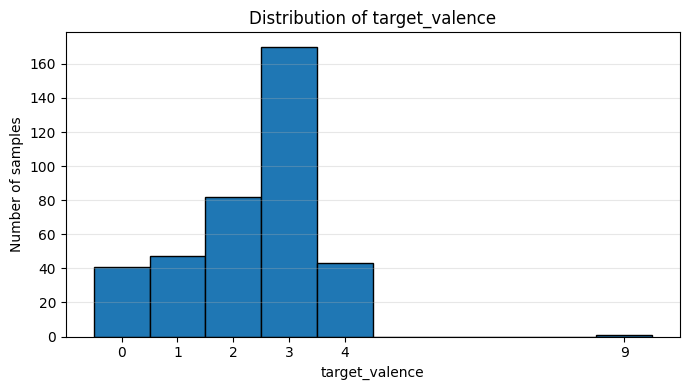

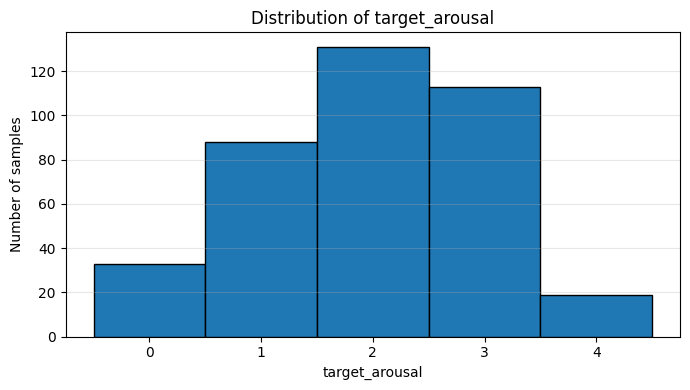

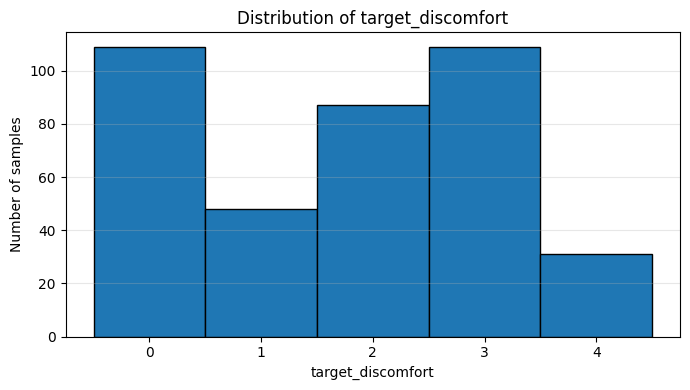

In [5]:
for col in target_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col].dropna(), bins=np.arange(df[col].min(), df[col].max() + 2) - 0.5, edgecolor="black")
    plt.xlabel(col)
    plt.ylabel("Number of samples")
    plt.title(f"Distribution of {col}")
    plt.xticks(sorted(df[col].dropna().unique()))
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/3263568580.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=scene_order, showmeans=True)


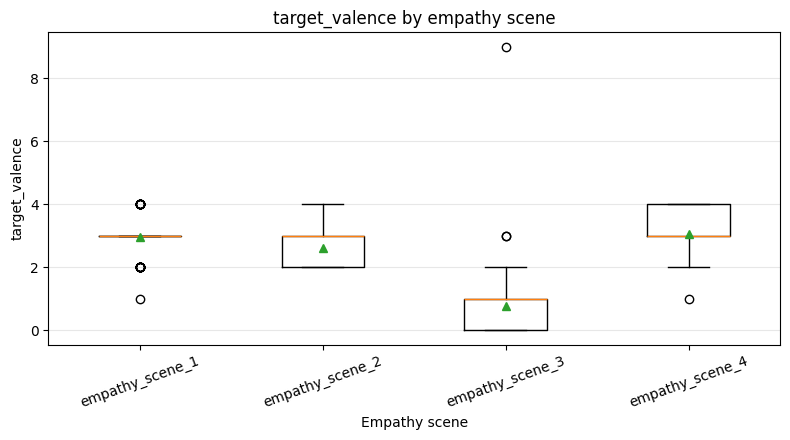

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/3263568580.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=scene_order, showmeans=True)


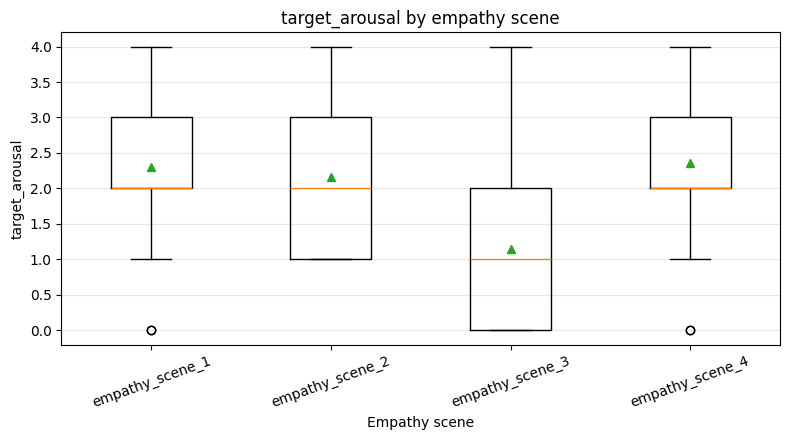

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/3263568580.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=scene_order, showmeans=True)


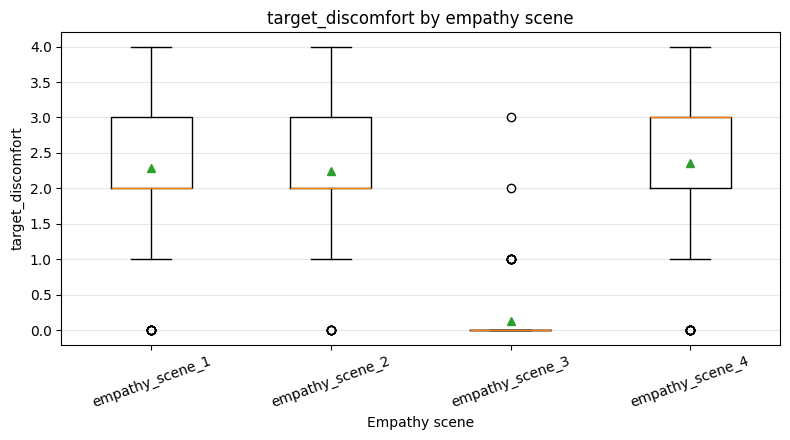

In [6]:
scene_order = [ #to be able to check if the emotional behaviour differs between different empathy scenes
    "empathy_scene_1",
    "empathy_scene_2",
    "empathy_scene_3",
    "empathy_scene_4",
]

for col in target_cols:
    plot_data = [
        df.loc[df["scene_name"] == scene, col].dropna()
        for scene in scene_order
    ]

    plt.figure(figsize=(8, 4.5))
    plt.boxplot(plot_data, labels=scene_order, showmeans=True)
    plt.xlabel("Empathy scene")
    plt.ylabel(col)
    plt.title(f"{col} by empathy scene")
    plt.xticks(rotation=20)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

The target distributions show that the self reported ratings are mainly defined on a 0–4 scale. Valence ratings are concentrated around the middle-to-higher part of the scale, especially around value 3, while arousal ratings are mostly concentrated around values 2 and 3. Discomfort shows a wider distribution, with many low discomfort responses but also a noticeable number of medium and high discomfort ratings.

The scene level plots suggest clear differences between the four empathy scenes. Empathy scene 3 appears to produce the lowest subjective emotional response overall, with lower valence, lower arousal and almost no discomfort compared with the other scenes. In contrast, scenes 1, 2 and 4 show higher arousal and discomfort, while scenes 1 and 4 also show higher valence ratings.


## Categorical Representation of Valence, Arousal and Discomfort

In addition to the original numerical ratings, the self reported targets are grouped into three broader categories: low, medium and high. Since the ratings in this dataset are mainly represented on a 0–4 scale, the thresholds are adapted accordingly. Ratings of 0 and 1 are treated as low, rating 2 as medium, and ratings of 3 or higher as high.


In [7]:
def bin_low_medium_high_0_4(x):
    if pd.isna(x):
        return np.nan
    if x <= 1:
        return "low"
    if x == 2:
        return "medium"
    if x >= 3:
        return "high"
    return "unknown"


df["valence_category"] = df["target_valence"].apply(bin_low_medium_high_0_4)
df["arousal_category"] = df["target_arousal"].apply(bin_low_medium_high_0_4)

category_cols = ["valence_category", "arousal_category"]

if "target_discomfort" in df.columns:
    df["discomfort_category"] = df["target_discomfort"].apply(bin_low_medium_high_0_4)
    category_cols.append("discomfort_category")

for col in category_cols:
    print(f"\nCategory counts for {col}:")
    display(df[col].value_counts(dropna=False).to_frame("count"))


Category counts for valence_category:


,count
valence_category,
high,214
low,88
medium,82



Category counts for arousal_category:


,count
arousal_category,
high,132
medium,131
low,121



Category counts for discomfort_category:


,count
discomfort_category,
low,157
high,140
medium,87


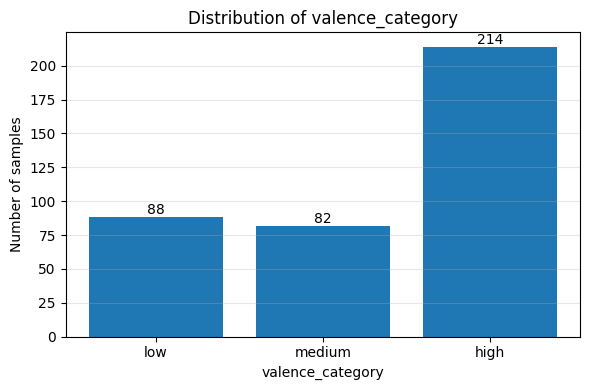

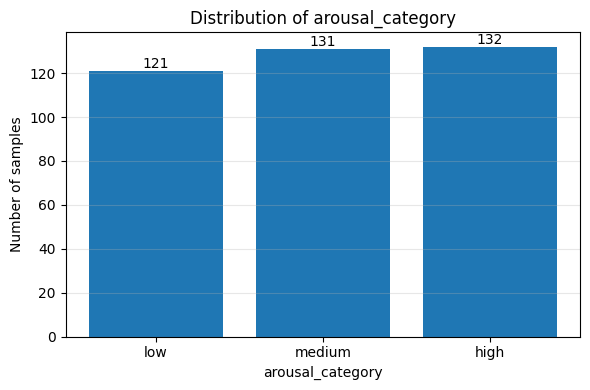

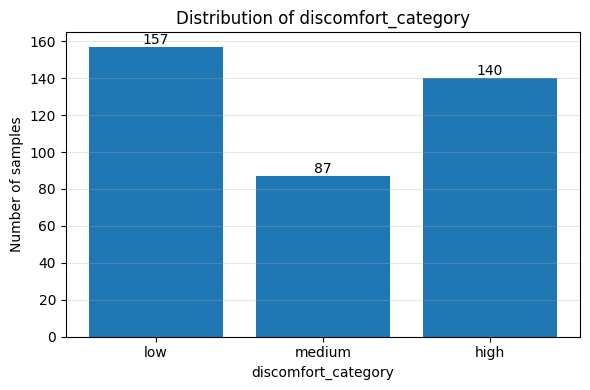

In [8]:
category_order = ["low", "medium", "high"]

for col in category_cols:
    counts = df[col].value_counts().reindex(category_order)

    plt.figure(figsize=(6, 4))
    plt.bar(counts.index, counts.values)
    plt.xlabel(col)
    plt.ylabel("Number of samples")
    plt.title(f"Distribution of {col}")
    plt.grid(axis="y", alpha=0.3)

    for i, value in enumerate(counts.values):
        plt.text(i, value, str(int(value)), ha="center", va="bottom")

    plt.tight_layout()
    plt.show()


valence_category by scene:


valence_category,low,medium,high
scene_name,,,
empathy_scene_1,1,14,81
empathy_scene_2,0,42,54
empathy_scene_3,86,7,3
empathy_scene_4,1,19,76


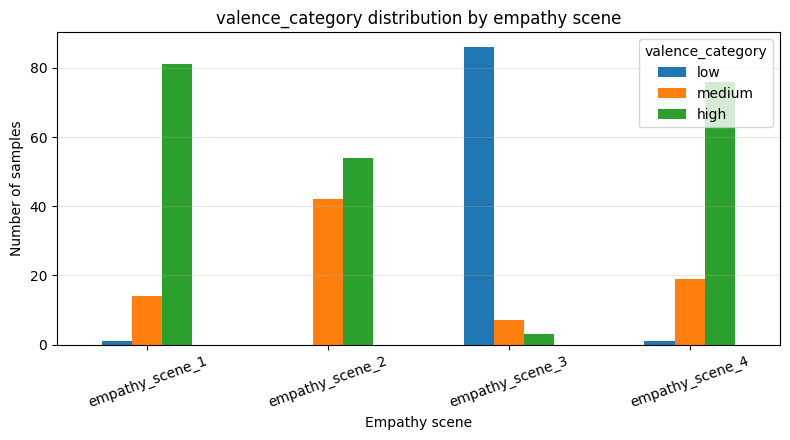


arousal_category by scene:


arousal_category,low,medium,high
scene_name,,,
empathy_scene_1,11,46,39
empathy_scene_2,27,31,38
empathy_scene_3,63,24,9
empathy_scene_4,20,30,46


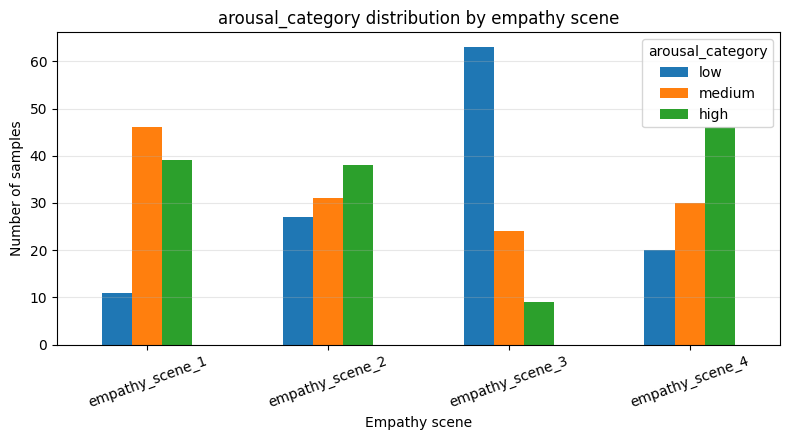


discomfort_category by scene:


discomfort_category,low,medium,high
scene_name,,,
empathy_scene_1,19,31,46
empathy_scene_2,23,31,42
empathy_scene_3,94,1,1
empathy_scene_4,21,24,51


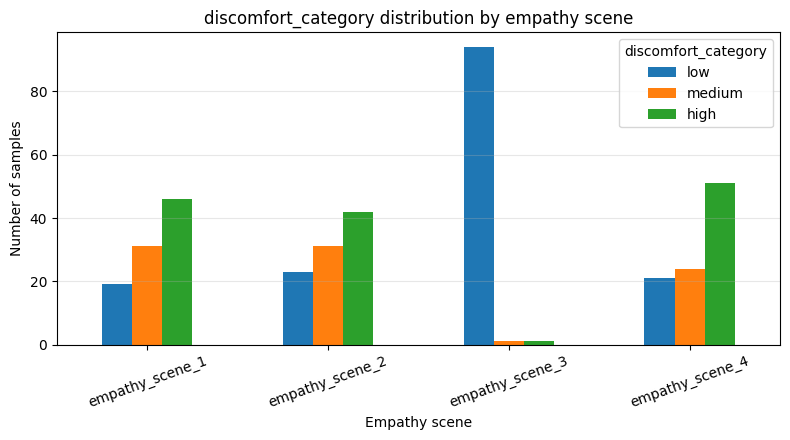

In [9]:
#categories by scene 
for col in category_cols: 
    ct = pd.crosstab(df["scene_name"], df[col])
    ct = ct.reindex(columns=category_order)

    print(f"\n{col} by scene:")
    display(ct)

    ax = ct.plot(kind="bar", figsize=(8, 4.5))
    ax.set_xlabel("Empathy scene")
    ax.set_ylabel("Number of samples")
    ax.set_title(f"{col} distribution by empathy scene")
    plt.xticks(rotation=20)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

The categorical representation of the targets shows that the 0–4 rating scale can be meaningfully grouped into low, medium and high categories. Ratings of 0 and 1 were treated as low, rating 2 as medium, and ratings of 3 or higher as high. This preserves the middle value of the scale as a separate category while still allowing broader interpretation of the affective responses.

The valence categories show that high valence responses are the most frequent overall, while low and medium valence are less represented. However, the distribution differs strongly between empathy scenes. Empathy scene 3 is dominated by low valence responses, while scenes 1 and 4 are mostly rated as high valence. Scene 2 contains mostly medium and high valence responses.

Arousal is more evenly distributed across the three categories, with a similar number of low, medium and high samples. This makes arousal suitable for further category-based exploratory analysis. At the scene level, empathy scene 3 again shows the lowest arousal response, while scenes 1, 2 and 4 contain more medium and high arousal ratings.

Discomfort shows a more polarized distribution, with many samples classified as either low or high discomfort and fewer samples in the medium category. Empathy scene 3 is almost entirely low discomfort, while scenes 1, 2 and 4 show higher discomfort responses.

Overall, the categorical analysis suggests that the four empathy scenes produced clearly different subjective affective responses. This is useful for the following analysis, but it also means that feature differences across affective categories should be interpreted carefully, because category effects may be partly confounded with scene effects.


## Relationships Between Self Reported Valence, Arousal and Discomfort

After inspecting the individual distributions of the self reported targets, the next step is to examine how these ratings relate to each other. This is important because valence, arousal and discomfort are not necessarily independent. For example, scenes with higher emotional intensity may also be rated as more arousing or more uncomfortable.

This analysis explores pairwise relationships between the three self report measures using correlation matrices, scatter plots and category cross tabulations. Since the ratings are ordinal and discrete, Spearman correlation is especially useful because it captures monotonic relationships without assuming normally distributed continuous variables.


In [10]:
self_report_cols = ["target_valence", "target_arousal"]

if "target_discomfort" in df.columns:
    self_report_cols.append("target_discomfort")

print("Pearson correlation:")
pearson_corr = df[self_report_cols].corr(method="pearson")
display(pearson_corr)

print("\nSpearman correlation:")
spearman_corr = df[self_report_cols].corr(method="spearman")
display(spearman_corr)

Pearson correlation:


,target_valence,target_arousal,target_discomfort
target_valence,1.000000,0.545710,0.673861
target_arousal,0.545710,1.000000,0.601351
target_discomfort,0.673861,0.601351,1.000000



Spearman correlation:


,target_valence,target_arousal,target_discomfort
target_valence,1.000000,0.558769,0.695587
target_arousal,0.558769,1.000000,0.596354
target_discomfort,0.695587,0.596354,1.000000


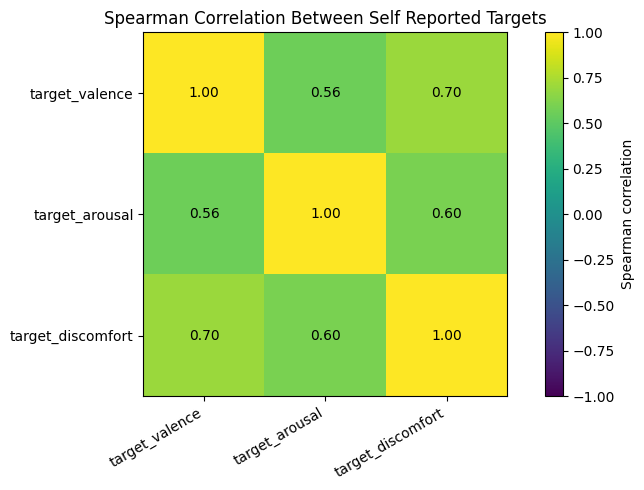

In [13]:
plt.figure(figsize=(8, 5))

corr_matrix = spearman_corr.copy()

im = plt.imshow(corr_matrix, vmin=-1, vmax=1)
plt.colorbar(im, label="Spearman correlation")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=30, ha="right")
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j, i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Spearman Correlation Between Self Reported Targets")
plt.tight_layout()
plt.show()

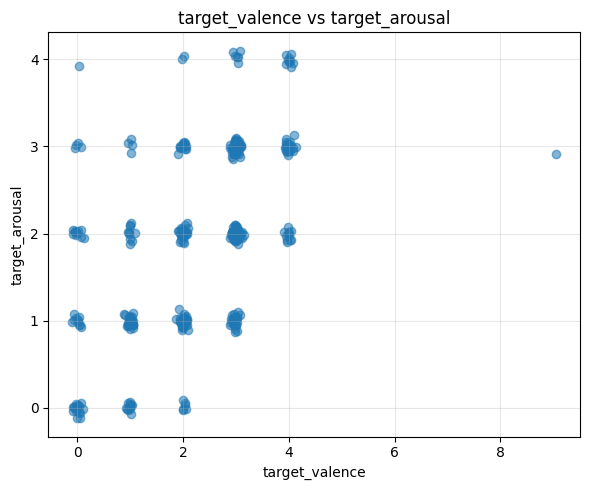

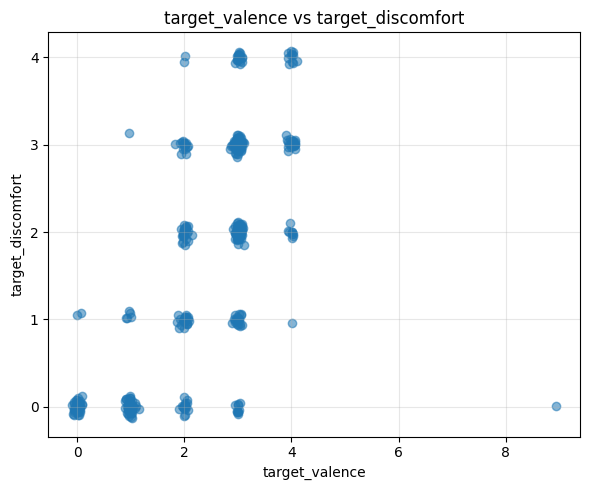

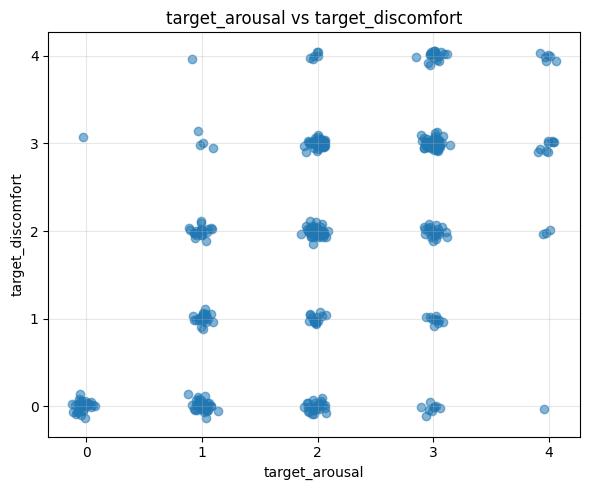

In [14]:
rng = np.random.default_rng(42)

target_pairs = [
    ("target_valence", "target_arousal"),
]

if "target_discomfort" in df.columns:
    target_pairs.extend([
        ("target_valence", "target_discomfort"),
        ("target_arousal", "target_discomfort"),
    ])

for x_col, y_col in target_pairs:
    plot_df = df[[x_col, y_col, "scene_name"]].dropna().copy()

    x_jitter = plot_df[x_col] + rng.normal(0, 0.05, size=len(plot_df))
    y_jitter = plot_df[y_col] + rng.normal(0, 0.05, size=len(plot_df))

    plt.figure(figsize=(6, 5))
    plt.scatter(x_jitter, y_jitter, alpha=0.55)

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"{x_col} vs {y_col}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [15]:
scene_target_summary = (
    df.groupby("scene_name")[self_report_cols]
    .agg(["mean", "median", "std"])
)

display(scene_target_summary)

target_valence                  target_arousal         \
                          mean median       std           mean median   
scene_name                                                              
empathy_scene_1       2.968750    3.0  0.570376       2.302083    2.0   
empathy_scene_2       2.614583    3.0  0.587050       2.156250    2.0   
empathy_scene_3       0.770833    1.0  1.100040       1.145833    1.0   
empathy_scene_4       3.041667    3.0  0.709584       2.364583    2.0   

                          target_discomfort                   
                      std              mean median       std  
scene_name                                                    
empathy_scene_1  0.769413          2.291667    2.0  1.065405  
empathy_scene_2  0.886485          2.239583    2.0  1.033592  
empathy_scene_3  0.983861          0.125000    0.0  0.441290  
empathy_scene_4  0.985364          2.354167    3.0  1.151467

### Category Level Relationships

In addition to numerical correlations, the categorical labels are compared using cross-tabulations. This helps show whether certain affective categories tend to appear together. For example, high valence may often occur together with high arousal or high discomfort, while low valence may be concentrated in specific scenes.


In [16]:
category_pairs = [
    ("valence_category", "arousal_category"),
]

if "discomfort_category" in df.columns:
    category_pairs.extend([
        ("valence_category", "discomfort_category"),
        ("arousal_category", "discomfort_category"),
    ])

category_order = ["low", "medium", "high"]

for row_col, col_col in category_pairs:
    print(f"\n{row_col} vs {col_col}:")
    
    ct = pd.crosstab(df[row_col], df[col_col])
    ct = ct.reindex(index=category_order, columns=category_order)
    display(ct)

    ct_norm = pd.crosstab(df[row_col], df[col_col], normalize="index")
    ct_norm = ct_norm.reindex(index=category_order, columns=category_order)
    
    print(f"\nRow-normalized {row_col} vs {col_col}:")
    display((ct_norm * 100).round(1))


valence_category vs arousal_category:


arousal_category,low,medium,high
valence_category,,,
low,59,20,9
medium,38,28,16
high,24,83,107



Row-normalized valence_category vs arousal_category:


arousal_category,low,medium,high
valence_category,,,
low,67.0,22.7,10.2
medium,46.3,34.1,19.5
high,11.2,38.8,50.0



valence_category vs discomfort_category:


...

discomfort_category,low,medium,high
valence_category,,,
low,98.9,0.0,1.1
medium,47.6,30.5,22.0
high,14.5,29.0,56.5



arousal_category vs discomfort_category:


discomfort_category,low,medium,high
arousal_category,,,
low,95,20,6
medium,41,41,49
high,21,26,85



Row-normalized arousal_category vs discomfort_category:


discomfort_category,low,medium,high
arousal_category,,,
low,78.5,16.5,5.0
medium,31.3,31.3,37.4
high,15.9,19.7,64.4


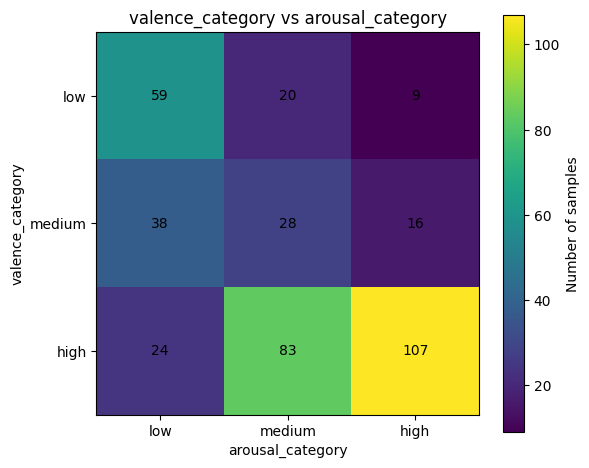

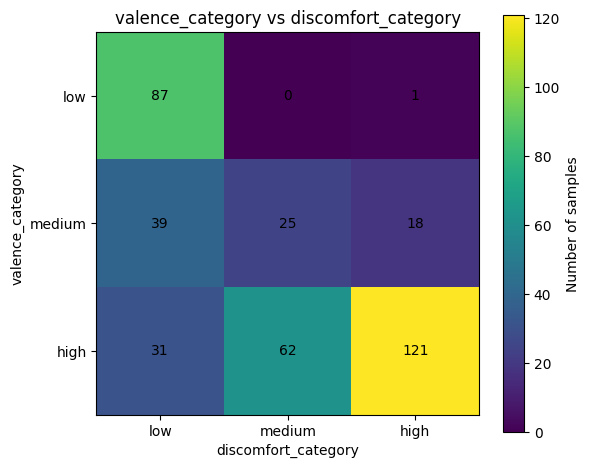

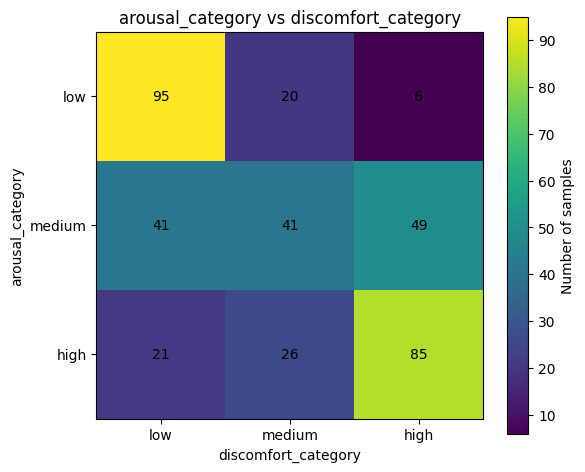

In [17]:
# Plot category cross-tabulations

category_pairs = [
    ("valence_category", "arousal_category"),
]

if "discomfort_category" in df.columns:
    category_pairs.extend([
        ("valence_category", "discomfort_category"),
        ("arousal_category", "discomfort_category"),
    ])

category_order = ["low", "medium", "high"]

for row_col, col_col in category_pairs:
    ct = pd.crosstab(df[row_col], df[col_col])
    ct = ct.reindex(index=category_order, columns=category_order)

    plt.figure(figsize=(6, 5))
    im = plt.imshow(ct.values)

    plt.colorbar(im, label="Number of samples")
    plt.xticks(range(len(category_order)), category_order)
    plt.yticks(range(len(category_order)), category_order)

    plt.xlabel(col_col)
    plt.ylabel(row_col)
    plt.title(f"{row_col} vs {col_col}")

    for i in range(ct.shape[0]):
        for j in range(ct.shape[1]):
            value = ct.iloc[i, j]
            plt.text(
                j, i,
                str(int(value)),
                ha="center",
                va="center"
            )

    plt.tight_layout()
    plt.show()

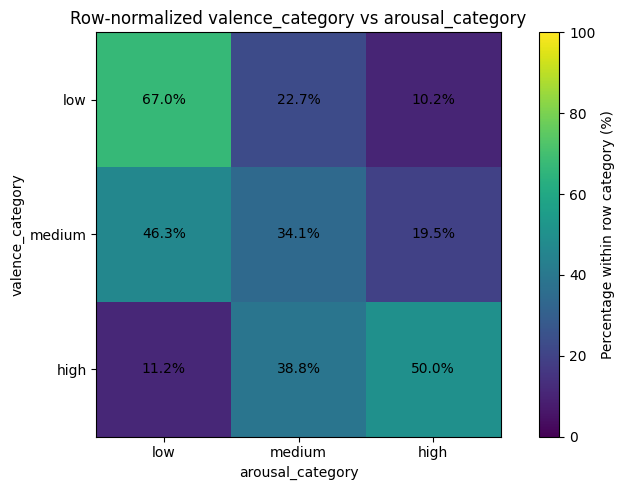

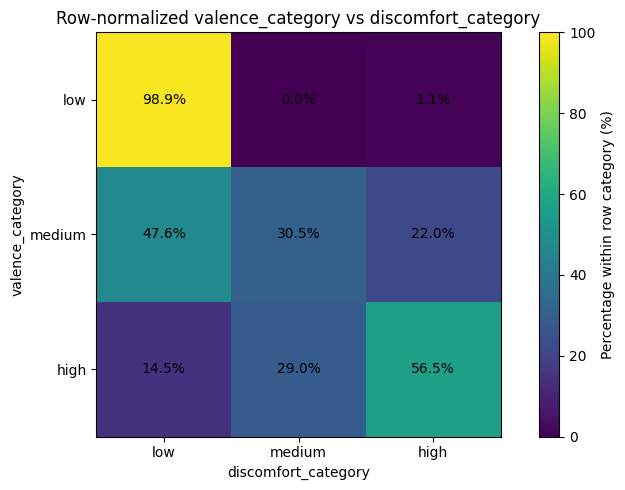

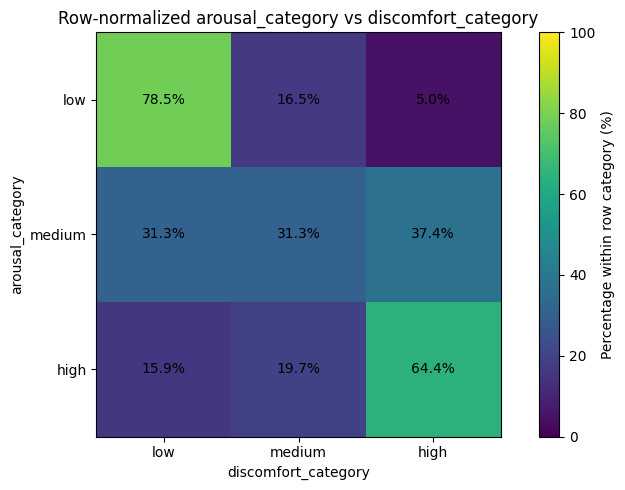

In [19]:
# Plot row-normalized category cross-tabulations

for row_col, col_col in category_pairs:
    ct_norm = pd.crosstab(df[row_col], df[col_col], normalize="index")
    ct_norm = ct_norm.reindex(index=category_order, columns=category_order) * 100

    plt.figure(figsize=(8, 5))
    im = plt.imshow(ct_norm.values, vmin=0, vmax=100)

    plt.colorbar(im, label="Percentage within row category (%)")
    plt.xticks(range(len(category_order)), category_order)
    plt.yticks(range(len(category_order)), category_order)

    plt.xlabel(col_col)
    plt.ylabel(row_col)
    plt.title(f"Row-normalized {row_col} vs {col_col}")

    for i in range(ct_norm.shape[0]):
        for j in range(ct_norm.shape[1]):
            value = ct_norm.iloc[i, j]
            plt.text(
                j, i,
                f"{value:.1f}%",
                ha="center",
                va="center"
            )

    plt.tight_layout()
    plt.show()

The relationships between the self reported targets show that valence, arousal and discomfort are positively associated with each other. The Spearman correlation matrix indicates a moderate positive relationship between valence and arousal, a stronger positive relationship between valence and discomfort, and a moderate to strong positive relationship between arousal and discomfort.

The scatter plots support these findings by showing that higher values of one self report measure often appear together with higher values of the others. Because the ratings are discrete, the points appear in clusters, but the overall monotonic pattern is still visible.

The category cross tabulations provide a clearer interpretation of these relationships. Low valence is mostly associated with low arousal and very low discomfort. In contrast, high valence is frequently associated with medium or high arousal and is most often paired with high discomfort. Similarly, low arousal is mostly associated with low discomfort, while high arousal is most often associated with high discomfort.

These results suggest that the self reported targets are not independent. In this dataset, stronger affective responses tend to appear across multiple dimensions at the same time. This is especially important for later feature level analyses, because a sensor feature associated with arousal may also partly reflect discomfort or scene level emotional intensity.


## Feature Groups and Missing Values

Before analyzing the relationship between sensor derived features and self reported emotional ratings, the feature space is inspected. The dataset contains multiple groups of features extracted from different sensor derived files, including facial activation, EMG activation, expression intensity, breathing rate, HRV and motion related features.

This section identifies the available feature groups, summarizes how many features belong to each group, and examines missing values. This is especially important because some features, such as expression specific intensity features, may be missing when a particular expression was not detected during a scene. Therefore, missingness needs to be interpreted carefully before deciding how to handle it in later analysis.


In [20]:
metadata_cols = {
    "participant_id",
    "participant_folder",
    "recording_suffix",
    "video_set",
    "scene_name",
    "scene_index",
    "target_valence",
    "target_arousal",
    "target_discomfort",
    "window_start",
    "window_end",
    "window_duration_seconds",
    "segment_duration_seconds",
    "trim_seconds_used",
    "timing_source",
    "feature_extraction_strategy",
    "valence_category",
    "arousal_category",
    "discomfort_category",
    "n_core_available_features",
}

feature_cols = [
    col for col in df.columns
    if col not in metadata_cols
    and not col.startswith("qc_")
]

print("Number of total columns:", df.shape[1])
print("Number of feature columns:", len(feature_cols))

print("\nFeature columns:")
display(pd.DataFrame({"feature": feature_cols}))

Number of total columns: 60
Number of feature columns: 36

Feature columns:


,feature
0,breathingrate_breathingrate_min
1,breathingrate_breathingrate_max
2,breathingrate_imu_motionintensity_min
3,breathingrate_imu_motionintensity_max
4,emgactivation_emg_amplitude_zygo_weighted_min
5,emgactivation_emg_amplitude_zygo_weighted_max
6,emgactivation_emg_amplitude_orbi_weighted_min
7,emgactivation_emg_amplitude_orbi_weighted_max
8,emgactivation_emg_amplitude_front_weighted_min
9,emgactivation_emg_amplitude_front_weighted_max


In [21]:
def get_feature_group(col):
    if col.startswith("emgactivation_"):
        return "emg_activation"
    if col.startswith("facialactivation_"):
        return "facial_activation"
    if col.startswith("expression_"):
        return "expression"
    if col.startswith("breathingrate_"):
        return "breathing_rate"
    if col.startswith("hrv_"):
        return "hrv"
    if "imu_motionintensity" in col:
        return "imu_motion"
    return "other"


feature_group_df = pd.DataFrame({
    "feature": feature_cols,
    "feature_group": [get_feature_group(col) for col in feature_cols],
    "missing_ratio": df[feature_cols].isna().mean().values,
    "missing_count": df[feature_cols].isna().sum().values,
})

display(feature_group_df)

print("Number of features by group:")
feature_group_counts = (
    feature_group_df["feature_group"]
    .value_counts()
    .sort_index()
    .to_frame("n_features")
)

display(feature_group_counts)

,feature,feature_group,missing_ratio,missing_count
0,breathingrate_breathingrate_min,breathing_rate,0.002604,1
1,breathingrate_breathingrate_max,breathing_rate,0.002604,1
2,breathingrate_imu_motionintensity_min,breathing_rate,0.000000,0
3,breathingrate_imu_motionintensity_max,breathing_rate,0.000000,0
4,emgactivation_emg_amplitude_zygo_weighted_min,emg_activation,0.000000,0
5,emgactivation_emg_amplitude_zygo_weighted_max,emg_activation,0.000000,0
6,emgactivation_emg_amplitude_orbi_weighted_min,emg_activation,0.000000,0
7,emgactivation_emg_amplitude_orbi_weighted_max,emg_activation,0.000000,0
8,emgactivation_emg_amplitude_front_weighted_min,emg_activation,0.000000,0
9,emgactivation_emg_amplitude_front_weighted_max,emg_activation,0.000000,0


Number of features by group:


,n_features
feature_group,
breathing_rate,4
emg_activation,8
expression,10
facial_activation,2
hrv,12


In [22]:
missing_summary = (
    feature_group_df
    .sort_values("missing_ratio", ascending=False)
    .reset_index(drop=True)
)

print("Features with highest missing ratio:")
display(missing_summary.head(20))

print("Missing ratio summary:")
display(missing_summary["missing_ratio"].describe().to_frame("missing_ratio"))

Features with highest missing ratio:


,feature,feature_group,missing_ratio,missing_count
0,breathingrate_breathingrate_min,breathing_rate,0.002604,1
1,breathingrate_breathingrate_max,breathing_rate,0.002604,1
2,hrv_hrv_rr_min,hrv,0.000000,0
3,hrv_hrv_rr_max,hrv,0.000000,0
4,hrv_hrv_sdnn_min,hrv,0.000000,0
5,hrv_hrv_sdnn_max,hrv,0.000000,0
6,hrv_hrv_sdsd_min,hrv,0.000000,0
7,hrv_hrv_sdsd_max,hrv,0.000000,0
8,hrv_hrv_rmssd_min,hrv,0.000000,0
9,hrv_hrv_rmssd_max,hrv,0.000000,0


Missing ratio summary:


,missing_ratio
count,36.000000
mean,0.000145
std,0.000605
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,0.002604


## Feature Distributions and Descriptive Statistics

After confirming that the feature dataset is complete, the next step is to inspect the distributions of the extracted sensor-derived features. This helps identify whether the features contain extreme values, strong skewness, or very different value ranges across feature groups.

The analysis is first performed using descriptive statistics for all feature columns. Afterwards, selected representative features from each sensor group are visualized. This provides an overview of the feature space before examining how these features relate to valence, arousal and discomfort.

The selected features include facial activation, EMG activation, expression intensity, breathing rate, HRV and motion-related features. This follows the general idea of affective sensing studies, where self-reported emotional ratings are examined in relation to physiological and facial activation signals.


In [25]:
feature_descriptive_stats = df[feature_cols].describe().T

feature_descriptive_stats["median"] = df[feature_cols].median()
feature_descriptive_stats["missing_count"] = df[feature_cols].isna().sum()
feature_descriptive_stats["missing_ratio"] = df[feature_cols].isna().mean()
feature_descriptive_stats["skewness"] = df[feature_cols].skew()

feature_descriptive_stats = feature_descriptive_stats[
    [
        "count",
        "mean",
        "std",
        "min",
        "25%",
        "median",
        "50%",
        "75%",
        "max",
        "missing_count",
        "missing_ratio",
        "skewness",
    ]
]

display(feature_descriptive_stats)

,count,mean,std,min,25%,median,50%,75%,max,missing_count,missing_ratio,skewness
breathingrate_breathingrate_min,383.0,10.754029,0.968164,8.410505,10.040305,10.677669,10.677669,11.444619,14.464328,1,0.002604,0.490753
breathingrate_breathingrate_max,383.0,15.264838,0.786836,12.850148,14.761161,15.355381,15.355381,15.839112,17.808004,1,0.002604,-0.347127
breathingrate_imu_motionintensity_min,384.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000
breathingrate_imu_motionintensity_max,384.0,0.044071,0.102645,0.000000,0.000000,0.000000,0.000000,0.076923,0.846154,0,0.000000,3.892477
emgactivation_emg_amplitude_zygo_weighted_min,384.0,0.920379,1.695597,-5.403480,-0.042761,0.522187,0.522187,1.270069,9.022626,0,0.000000,1.620765
emgactivation_emg_amplitude_zygo_weighted_max,384.0,48.265447,44.798407,0.930421,14.718658,33.652630,33.652630,65.363910,280.625786,0,0.000000,1.777660
emgactivation_emg_amplitude_orbi_weighted_min,384.0,2.179613,5.086826,-7.656689,-0.008691,0.702356,0.702356,2.378192,31.692658,0,0.000000,3.107314
emgactivation_emg_amplitude_orbi_weighted_max,384.0,89.038496,95.787200,3.954475,29.153137,57.382791,57.382791,113.281146,645.921452,0,0.000000,2.457620
emgactivation_emg_amplitude_front_weighted_min,384.0,3.587907,5.880495,-7.290689,0.419072,1.552270,1.552270,5.115432,54.089053,0,0.000000,3.414835
emgactivation_emg_amplitude_front_weighted_max,384.0,60.391967,53.953437,3.776730,26.074778,47.314361,47.314361,71.963788,369.423882,0,0.000000,2.231031


In [26]:
#features that have imbalanced/asymetric distribution
skewness_summary = (
    feature_descriptive_stats[["skewness"]]
    .assign(abs_skewness=lambda x: x["skewness"].abs())
    .sort_values("abs_skewness", ascending=False)
)

print("Features with strongest absolute skewness:")
display(skewness_summary.head(15))

Features with strongest absolute skewness:


,skewness,abs_skewness
emgactivation_emg_amplitude_corr_weighted_max,7.305164,7.305164
expression_frown_intensity_max,5.741602,5.741602
expression_eyebrow_raise_intensity_min,4.968678,4.968678
expression_frown_intensity_min,4.591660,4.591660
hrv_imu_motionintensity_max,4.221761,4.221761
breathingrate_imu_motionintensity_max,3.892477,3.892477
emgactivation_emg_amplitude_front_weighted_min,3.414835,3.414835
expression_eyebrow_raise_intensity_max,3.157540,3.157540
emgactivation_emg_amplitude_orbi_weighted_min,3.107314,3.107314
emgactivation_emg_amplitude_orbi_weighted_max,2.457620,2.457620


In [29]:
#selected features for plots

selected_features = [
    # Facial activation
    "facialactivation_facialactivation_min",
    "facialactivation_facialactivation_max",

    # EMG activation
    "emgactivation_emg_amplitude_zygo_weighted_min",
    "emgactivation_emg_amplitude_zygo_weighted_max",
    "emgactivation_emg_amplitude_corr_weighted_min",
    "emgactivation_emg_amplitude_corr_weighted_max",
    "emgactivation_emg_amplitude_front_weighted_min",
    "emgactivation_emg_amplitude_front_weighted_max",
    "emgactivation_emg_amplitude_orbi_weighted_min",
    "emgactivation_emg_amplitude_orbi_weighted_max",

    # Expression intensity
    "expression_expression_intensity_min",
    "expression_expression_intensity_max",
    "expression_smile_intensity_min",
    "expression_smile_intensity_max",
    "expression_frown_intensity_min",
    "expression_frown_intensity_max",
    "expression_eyebrow_raise_intensity_min",
    "expression_eyebrow_raise_intensity_max",

    # Breathing / HRV / motion
    "breathingrate_breathingrate_min",
    "breathingrate_breathingrate_max",
    "hrv_hrv_mean_hr_min",
    "hrv_hrv_mean_hr_max",
    "hrv_hrv_rmssd_min",
    "hrv_hrv_rmssd_max",
    "hrv_imu_motionintensity_min",
    "hrv_imu_motionintensity_max",
]

selected_features = [col for col in selected_features if col in df.columns]

print("Selected features for visualization:")
display(pd.DataFrame({"feature": selected_features}))

Selected features for visualization:


,feature
0,facialactivation_facialactivation_min
1,facialactivation_facialactivation_max
2,emgactivation_emg_amplitude_zygo_weighted_min
3,emgactivation_emg_amplitude_zygo_weighted_max
4,emgactivation_emg_amplitude_corr_weighted_min
5,emgactivation_emg_amplitude_corr_weighted_max
6,emgactivation_emg_amplitude_front_weighted_min
7,emgactivation_emg_amplitude_front_weighted_max
8,emgactivation_emg_amplitude_orbi_weighted_min
9,emgactivation_emg_amplitude_orbi_weighted_max


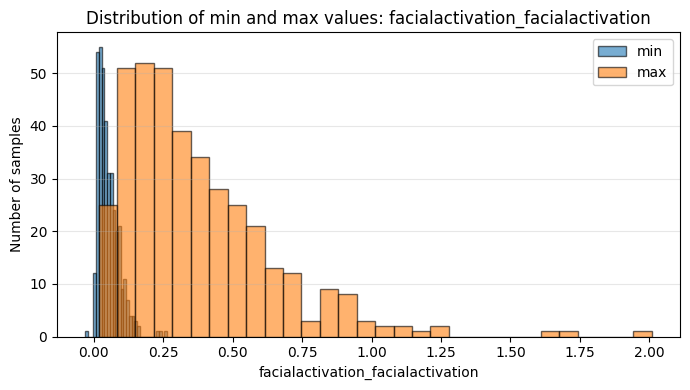

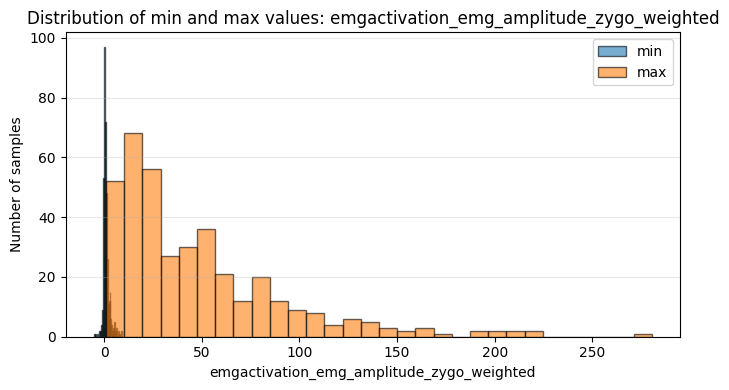

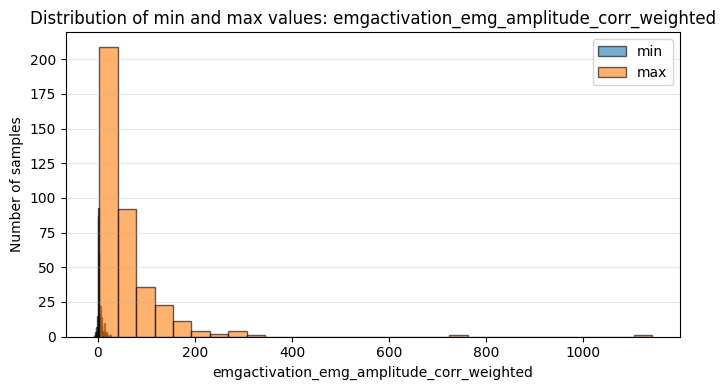

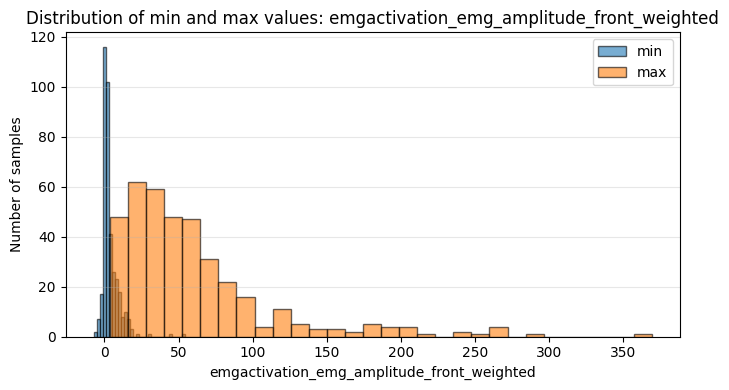

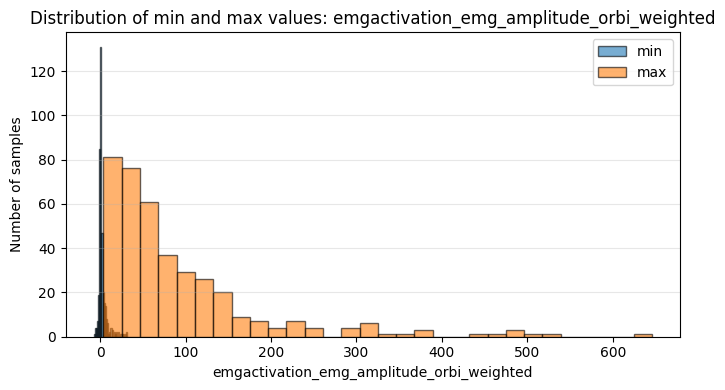

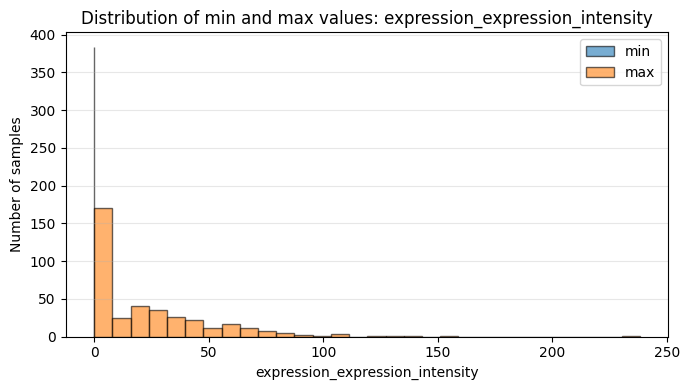

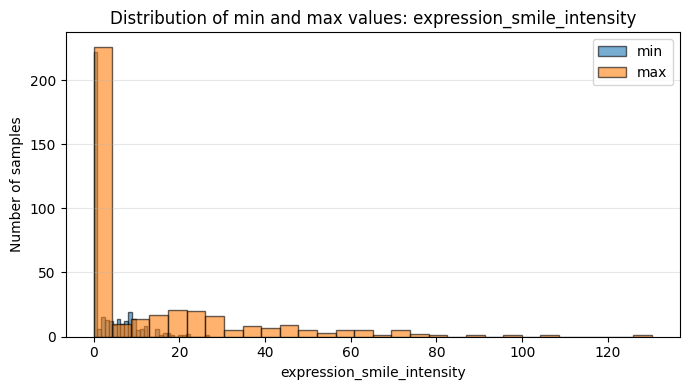

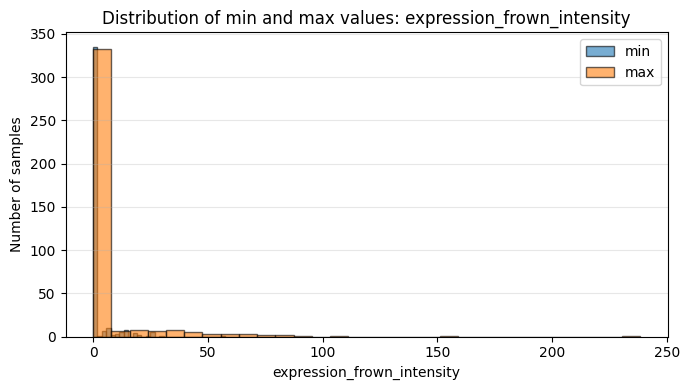

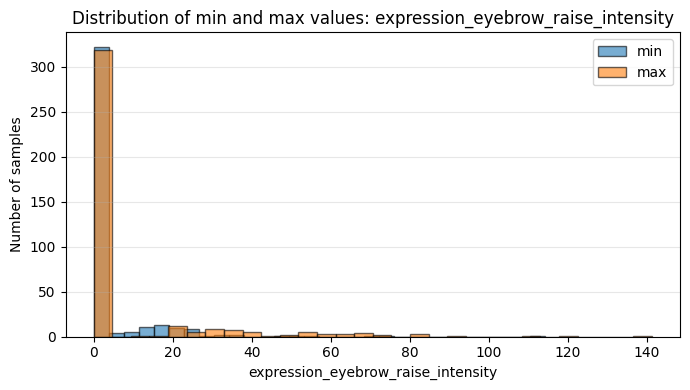

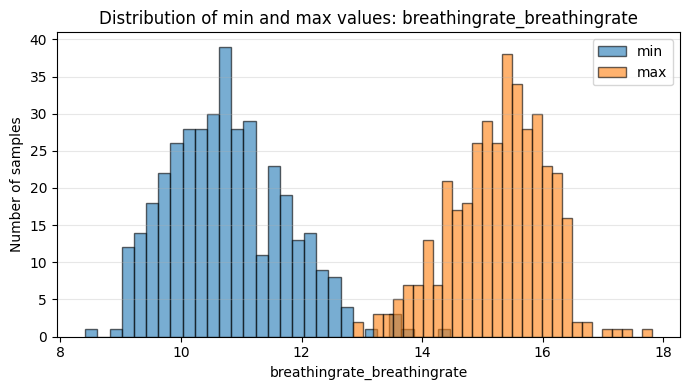

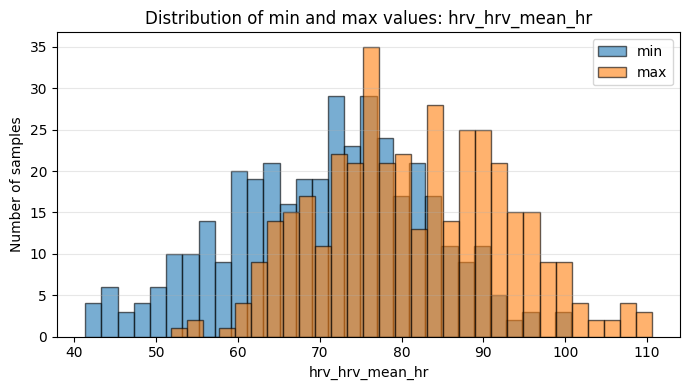

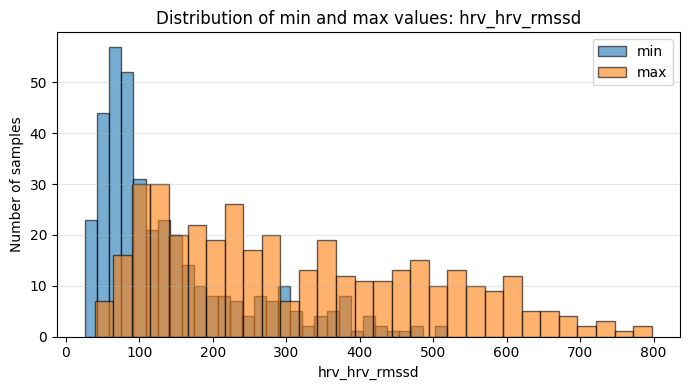

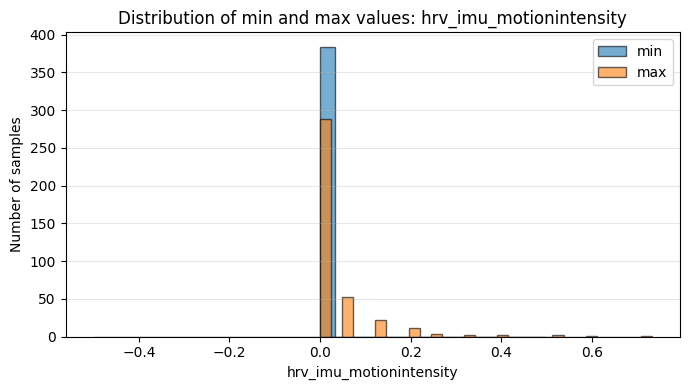

In [30]:
feature_pairs = [
    ("facialactivation_facialactivation_min", "facialactivation_facialactivation_max"),
    ("emgactivation_emg_amplitude_zygo_weighted_min", "emgactivation_emg_amplitude_zygo_weighted_max"),
    ("emgactivation_emg_amplitude_corr_weighted_min", "emgactivation_emg_amplitude_corr_weighted_max"),
    ("emgactivation_emg_amplitude_front_weighted_min", "emgactivation_emg_amplitude_front_weighted_max"),
    ("emgactivation_emg_amplitude_orbi_weighted_min", "emgactivation_emg_amplitude_orbi_weighted_max"),
    ("expression_expression_intensity_min", "expression_expression_intensity_max"),
    ("expression_smile_intensity_min", "expression_smile_intensity_max"),
    ("expression_frown_intensity_min", "expression_frown_intensity_max"),
    ("expression_eyebrow_raise_intensity_min", "expression_eyebrow_raise_intensity_max"),
    ("breathingrate_breathingrate_min", "breathingrate_breathingrate_max"),
    ("hrv_hrv_mean_hr_min", "hrv_hrv_mean_hr_max"),
    ("hrv_hrv_rmssd_min", "hrv_hrv_rmssd_max"),
    ("hrv_imu_motionintensity_min", "hrv_imu_motionintensity_max"),
]

feature_pairs = [
    (min_col, max_col)
    for min_col, max_col in feature_pairs
    if min_col in df.columns and max_col in df.columns
]

for min_col, max_col in feature_pairs:
    plt.figure(figsize=(7, 4))

    plt.hist(df[min_col].dropna(), bins=30, alpha=0.6, label="min", edgecolor="black")
    plt.hist(df[max_col].dropna(), bins=30, alpha=0.6, label="max", edgecolor="black")

    base_name = min_col.replace("_min", "")
    plt.xlabel(base_name)
    plt.ylabel("Number of samples")
    plt.title(f"Distribution of min and max values: {base_name}")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1022744405.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


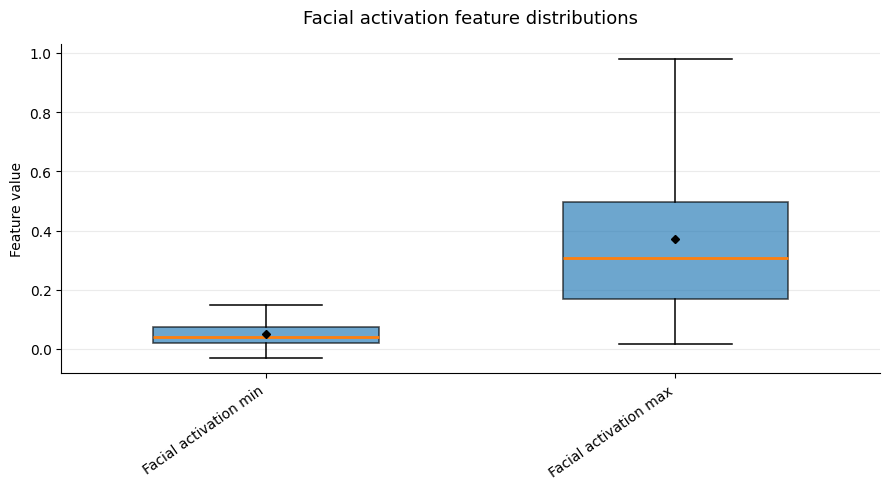

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1022744405.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


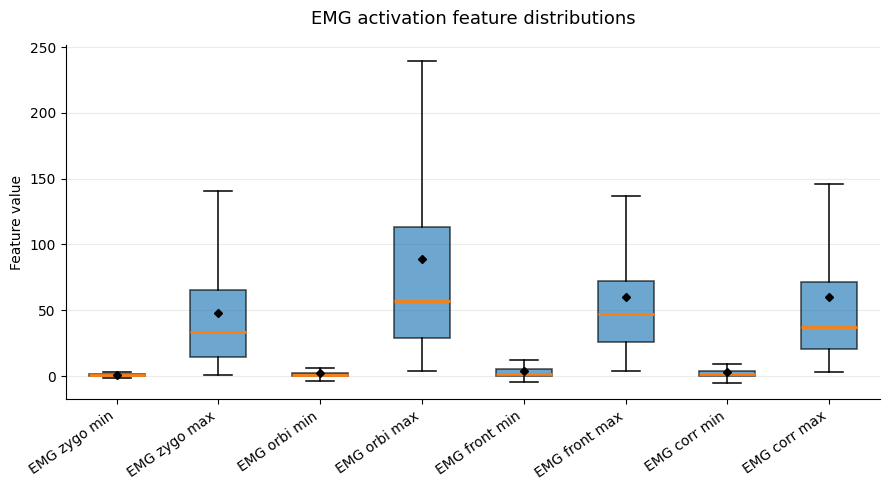

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1022744405.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


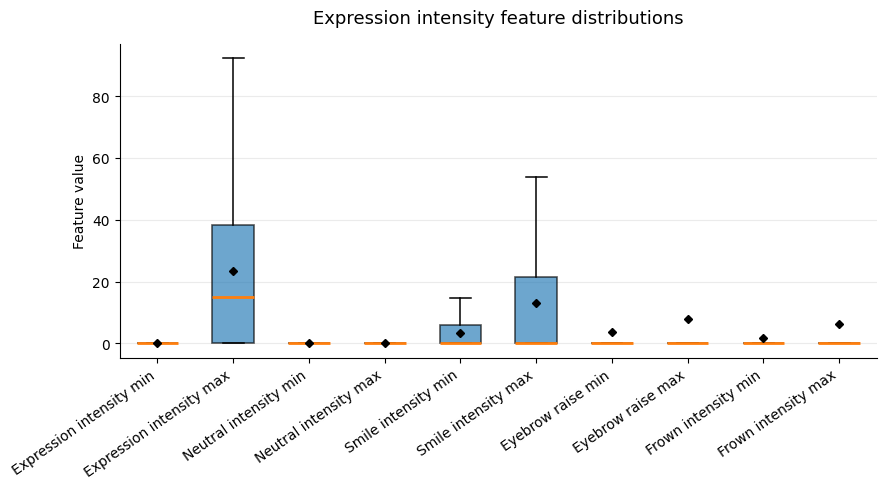

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1022744405.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


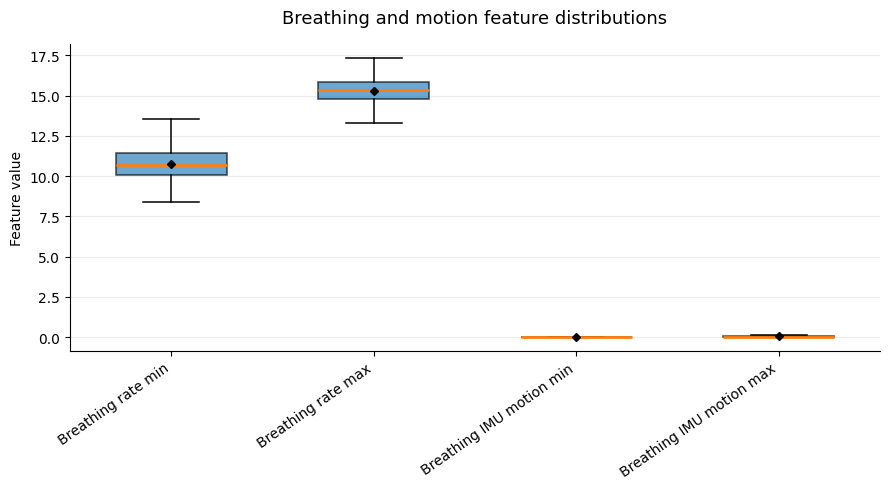

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1022744405.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


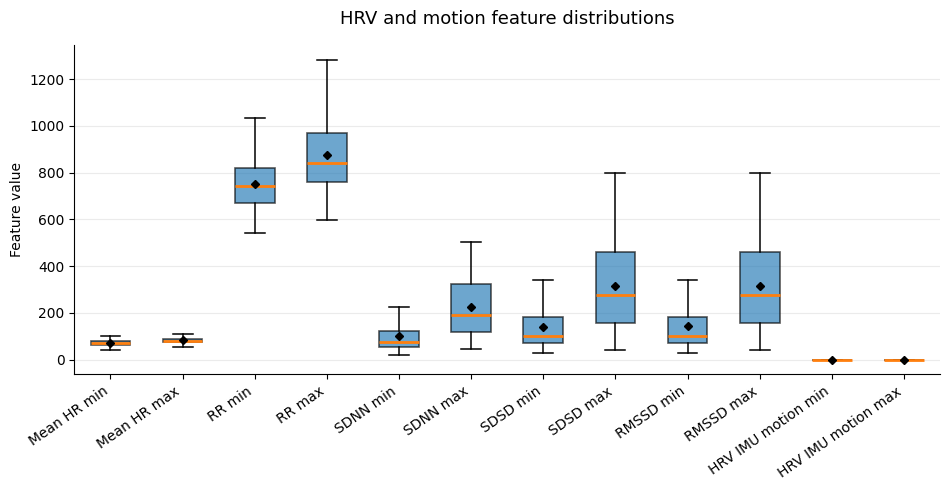

In [35]:
def clean_feature_label(col):
    label = col

    replacements = {
        "breathingrate_breathingrate": "Breathing rate",
        "breathingrate_imu_motionintensity": "Breathing IMU motion",
        "emgactivation_emg_amplitude_zygo_weighted": "EMG zygo",
        "emgactivation_emg_amplitude_orbi_weighted": "EMG orbi",
        "emgactivation_emg_amplitude_front_weighted": "EMG front",
        "emgactivation_emg_amplitude_corr_weighted": "EMG corr",
        "expression_expression_intensity": "Expression intensity",
        "expression_neutral_intensity": "Neutral intensity",
        "expression_smile_intensity": "Smile intensity",
        "expression_eyebrow_raise_intensity": "Eyebrow raise",
        "expression_frown_intensity": "Frown intensity",
        "facialactivation_facialactivation": "Facial activation",
        "hrv_hrv_mean_hr": "Mean HR",
        "hrv_hrv_rr": "RR",
        "hrv_hrv_sdnn": "SDNN",
        "hrv_hrv_sdsd": "SDSD",
        "hrv_hrv_rmssd": "RMSSD",
        "hrv_imu_motionintensity": "HRV IMU motion",
    }

    for old, new in replacements.items():
        label = label.replace(old, new)

    label = label.replace("_min", " min")
    label = label.replace("_max", " max")
    label = label.replace("_", " ")

    return label


feature_groups_to_plot = {
    "Facial activation": [
        "facialactivation_facialactivation_min",
        "facialactivation_facialactivation_max",
    ],
    "EMG activation": [
        "emgactivation_emg_amplitude_zygo_weighted_min",
        "emgactivation_emg_amplitude_zygo_weighted_max",
        "emgactivation_emg_amplitude_orbi_weighted_min",
        "emgactivation_emg_amplitude_orbi_weighted_max",
        "emgactivation_emg_amplitude_front_weighted_min",
        "emgactivation_emg_amplitude_front_weighted_max",
        "emgactivation_emg_amplitude_corr_weighted_min",
        "emgactivation_emg_amplitude_corr_weighted_max",
    ],
    "Expression intensity": [
        "expression_expression_intensity_min",
        "expression_expression_intensity_max",
        "expression_neutral_intensity_min",
        "expression_neutral_intensity_max",
        "expression_smile_intensity_min",
        "expression_smile_intensity_max",
        "expression_eyebrow_raise_intensity_min",
        "expression_eyebrow_raise_intensity_max",
        "expression_frown_intensity_min",
        "expression_frown_intensity_max",
    ],
    "Breathing and motion": [
        "breathingrate_breathingrate_min",
        "breathingrate_breathingrate_max",
        "breathingrate_imu_motionintensity_min",
        "breathingrate_imu_motionintensity_max",
    ],
    "HRV and motion": [
        "hrv_hrv_mean_hr_min",
        "hrv_hrv_mean_hr_max",
        "hrv_hrv_rr_min",
        "hrv_hrv_rr_max",
        "hrv_hrv_sdnn_min",
        "hrv_hrv_sdnn_max",
        "hrv_hrv_sdsd_min",
        "hrv_hrv_sdsd_max",
        "hrv_hrv_rmssd_min",
        "hrv_hrv_rmssd_max",
        "hrv_imu_motionintensity_min",
        "hrv_imu_motionintensity_max",
    ],
}


for group_name, cols in feature_groups_to_plot.items():
    cols = [col for col in cols if col in df.columns]

    if len(cols) == 0:
        continue

    plot_data = [df[col].dropna() for col in cols]
    labels = [clean_feature_label(col) for col in cols]

    plt.figure(figsize=(max(9, len(cols) * 0.8), 5))

    box = plt.boxplot(
        plot_data,
        labels=labels,
        patch_artist=True,
        showmeans=True,
        showfliers=False,
        widths=0.55,
        medianprops={"linewidth": 2},
        meanprops={
            "marker": "D",
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markersize": 4,
        },
        boxprops={"linewidth": 1.2},
        whiskerprops={"linewidth": 1.1},
        capprops={"linewidth": 1.1},
    )

    for patch in box["boxes"]:
        patch.set_alpha(0.65)

    plt.title(f"{group_name} feature distributions", fontsize=13, pad=15)
    plt.ylabel("Feature value")
    plt.xticks(rotation=35, ha="right")
    plt.grid(axis="y", alpha=0.25)

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

The feature distribution plots show clear differences between the minimum and maximum values extracted from each scene window. Across most facial and EMG related features, maximum values show substantially wider distributions than minimum values. This suggests that the peak activation within a scene window is likely to be more informative for affective response analysis than the lowest observed value.

Facial activation maximum values vary considerably across samples, while facial activation minimum values remain close to zero. A similar pattern is visible in the EMG activation features, where maximum amplitudes show much larger variability than minimum amplitudes. Among the EMG features, the orbicularis related activation shows the largest range, followed by frontal, corrugator and zygomaticus activation.

Expression related features show that overall expression intensity and smile intensity have the clearest variability across samples. In contrast, frown and eyebrow raise intensities are mostly close to zero, indicating that these expressions were less frequently detected or occurred with lower intensity in the extracted windows. Since expression specific missing values were previously encoded as zero, these values should be interpreted as absence or very low intensity of the detected expression rather than missing data.

The physiological features also show meaningful variability. Breathing rate has a relatively stable range, while HRV related measures such as RR, SDNN, SDSD and RMSSD show broader distributions. Motion intensity features are on a much smaller numerical scale compared with breathing rate and HRV features, so they should be interpreted carefully when plotted together with features that have larger value ranges.

Overall, the feature distributions indicate that the dataset contains meaningful variability across facial, expression related and physiological signals. Since the features are measured on different scales, later analyses should focus on within-feature comparisons across affective categories rather than directly comparing raw magnitudes between unrelated feature types.


## Feature Differences Across Empathy Scenes

The previous sections showed that the four empathy scenes produced different self reported affective responses. Because of this, it is important to inspect whether the sensor derived features also differ across scenes before directly comparing them with valence, arousal or discomfort categories.

This section visualizes selected representative features across the four empathy scenes. The goal is to identify whether some scenes are associated with stronger facial activation, expression intensity, physiological changes or motion-related responses. These scene level patterns will help interpret later analyses based on affective categories.


In [36]:
scene_order = [
    "empathy_scene_1",
    "empathy_scene_2",
    "empathy_scene_3",
    "empathy_scene_4",
]

scene_features = [
    # Facial / EMG activation
    "facialactivation_facialactivation_max",
    "emgactivation_emg_amplitude_zygo_weighted_max",
    "emgactivation_emg_amplitude_corr_weighted_max",
    "emgactivation_emg_amplitude_front_weighted_max",
    "emgactivation_emg_amplitude_orbi_weighted_max",

    # Expressions
    "expression_expression_intensity_max",
    "expression_smile_intensity_max",
    "expression_frown_intensity_max",
    "expression_eyebrow_raise_intensity_max",

    # Physiological / motion
    "breathingrate_breathingrate_max",
    "hrv_hrv_mean_hr_max",
    "hrv_hrv_rmssd_max",
    "hrv_imu_motionintensity_max",
]

scene_features = [col for col in scene_features if col in df.columns]

display(pd.DataFrame({"selected_scene_feature": scene_features}))

,selected_scene_feature
0,facialactivation_facialactivation_max
1,emgactivation_emg_amplitude_zygo_weighted_max
2,emgactivation_emg_amplitude_corr_weighted_max
3,emgactivation_emg_amplitude_front_weighted_max
4,emgactivation_emg_amplitude_orbi_weighted_max
5,expression_expression_intensity_max
6,expression_smile_intensity_max
7,expression_frown_intensity_max
8,expression_eyebrow_raise_intensity_max
9,breathingrate_breathingrate_max


In [37]:
def clean_feature_label(col):
    label = col

    replacements = {
        "breathingrate_breathingrate": "Breathing rate",
        "breathingrate_imu_motionintensity": "Breathing IMU motion",
        "emgactivation_emg_amplitude_zygo_weighted": "EMG zygo",
        "emgactivation_emg_amplitude_orbi_weighted": "EMG orbi",
        "emgactivation_emg_amplitude_front_weighted": "EMG front",
        "emgactivation_emg_amplitude_corr_weighted": "EMG corr",
        "expression_expression_intensity": "Expression intensity",
        "expression_neutral_intensity": "Neutral intensity",
        "expression_smile_intensity": "Smile intensity",
        "expression_eyebrow_raise_intensity": "Eyebrow raise",
        "expression_frown_intensity": "Frown intensity",
        "facialactivation_facialactivation": "Facial activation",
        "hrv_hrv_mean_hr": "Mean HR",
        "hrv_hrv_rr": "RR",
        "hrv_hrv_sdnn": "SDNN",
        "hrv_hrv_sdsd": "SDSD",
        "hrv_hrv_rmssd": "RMSSD",
        "hrv_imu_motionintensity": "HRV IMU motion",
    }

    for old, new in replacements.items():
        label = label.replace(old, new)

    label = label.replace("_min", " min")
    label = label.replace("_max", " max")
    label = label.replace("_", " ")

    return label

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1884473632.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


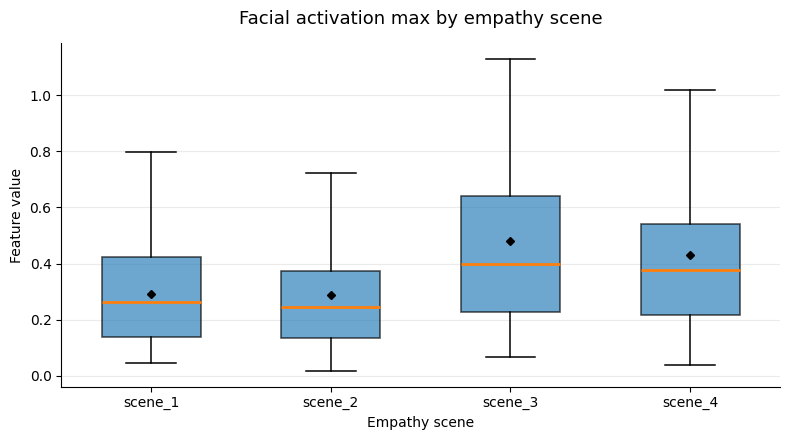

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1884473632.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


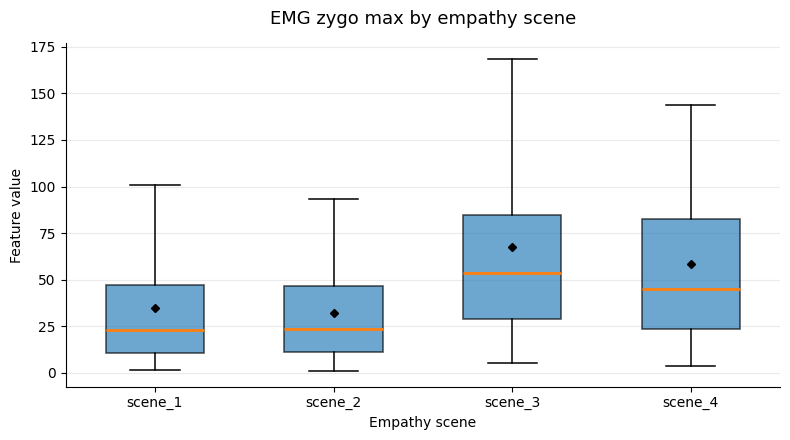

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1884473632.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


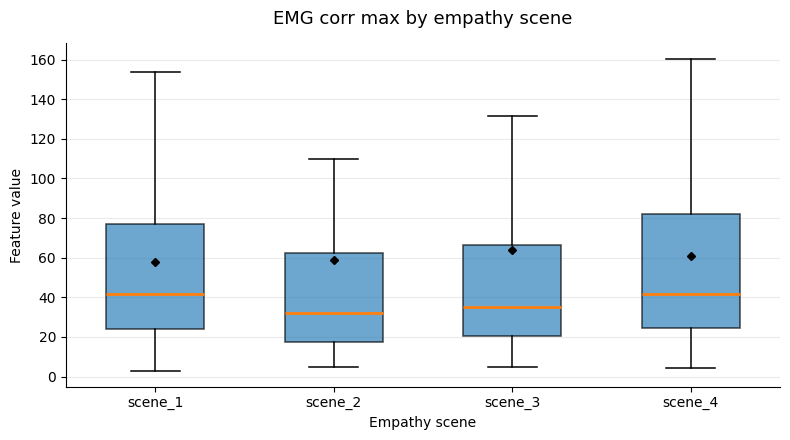

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1884473632.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


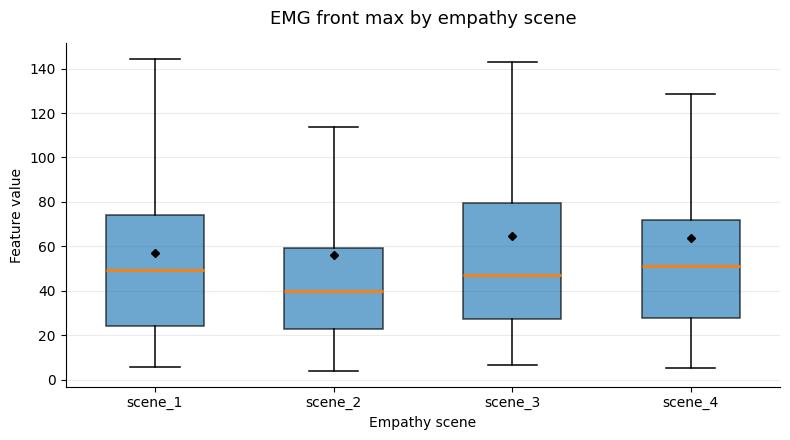

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1884473632.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


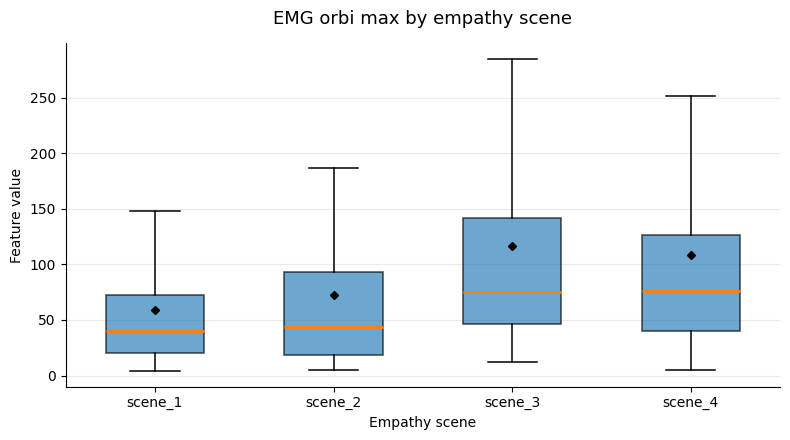

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1884473632.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


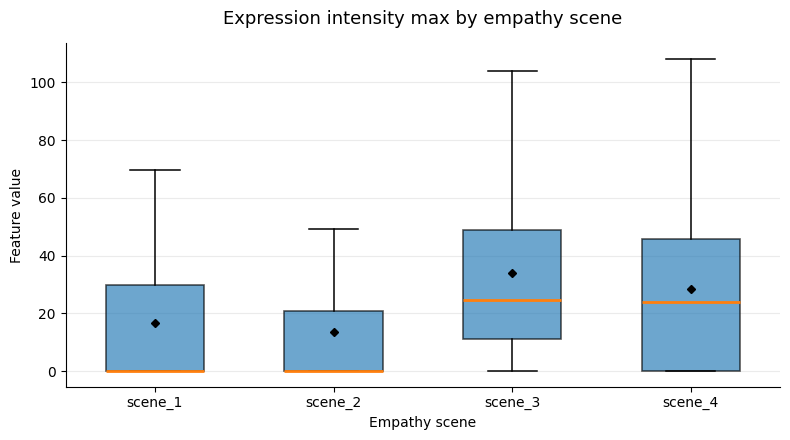

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1884473632.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


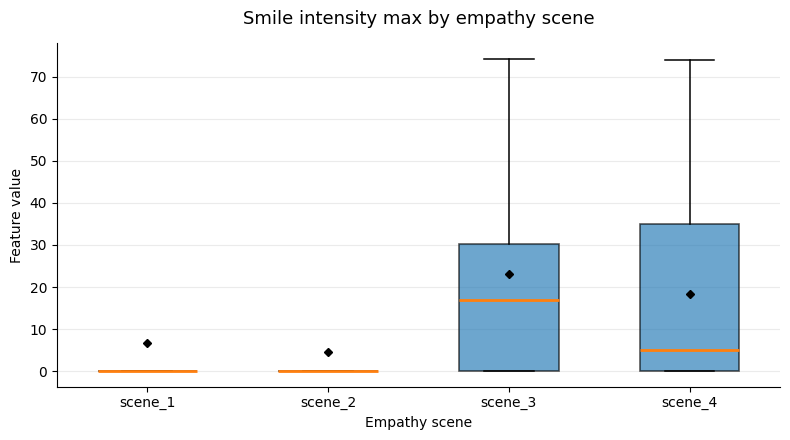

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1884473632.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


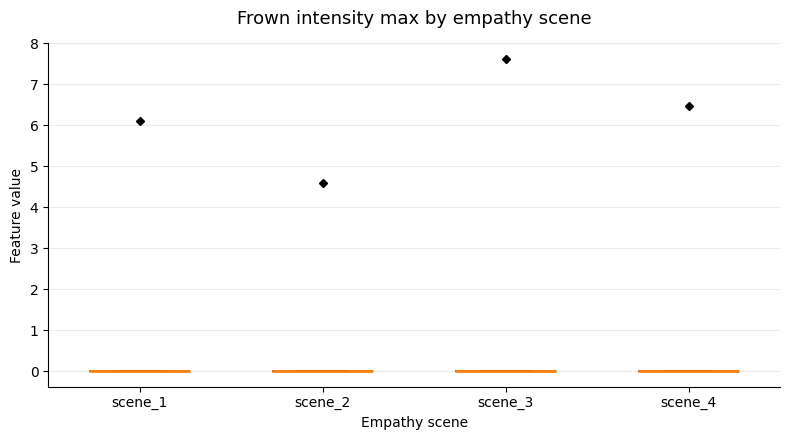

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1884473632.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


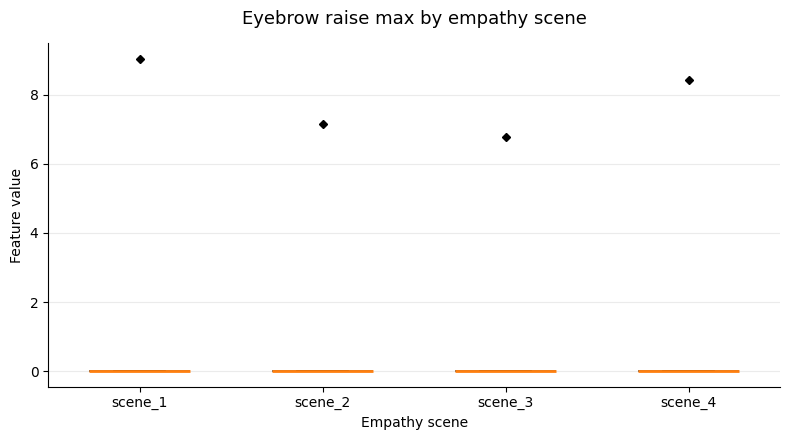

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1884473632.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


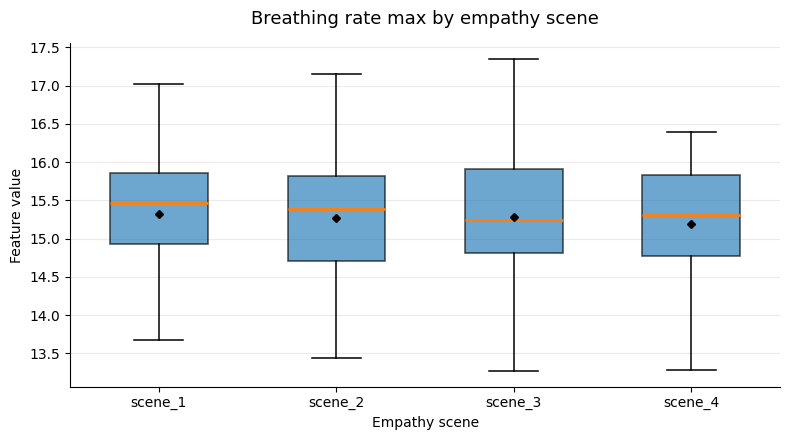

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1884473632.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


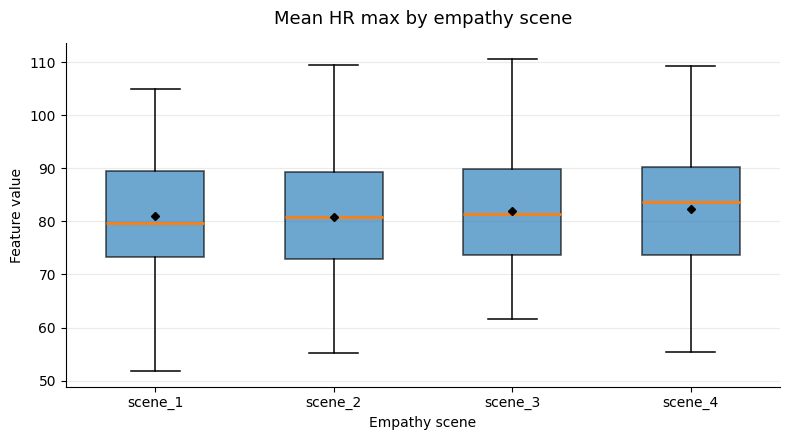

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1884473632.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


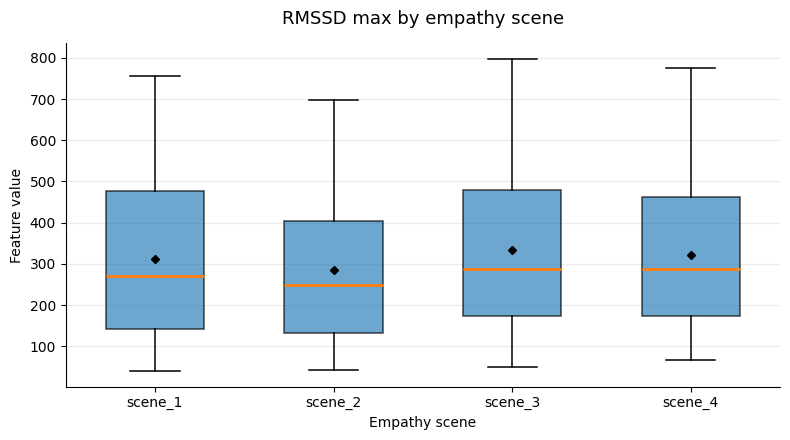

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1884473632.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


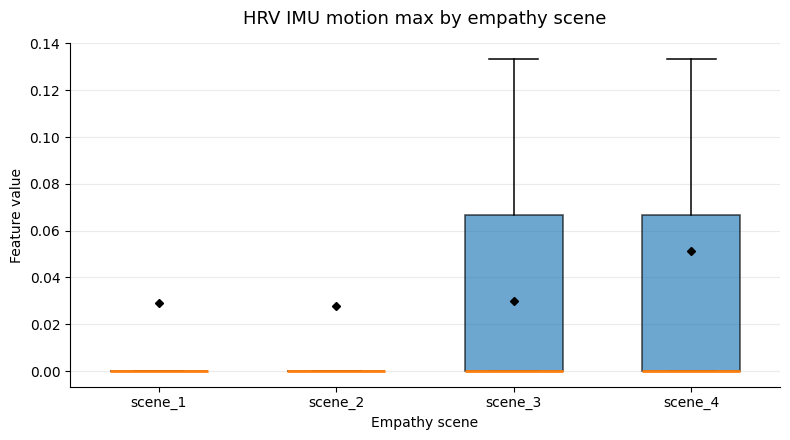

In [38]:
for feature in scene_features:
    plot_data = [
        df.loc[df["scene_name"] == scene, feature].dropna()
        for scene in scene_order
    ]

    plt.figure(figsize=(8, 4.5))

    box = plt.boxplot(
        plot_data,
        labels=[scene.replace("empathy_", "") for scene in scene_order],
        patch_artist=True,
        showmeans=True,
        showfliers=False,
        widths=0.55,
        medianprops={"linewidth": 2},
        meanprops={
            "marker": "D",
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markersize": 4,
        },
        boxprops={"linewidth": 1.2},
        whiskerprops={"linewidth": 1.1},
        capprops={"linewidth": 1.1},
    )

    for patch in box["boxes"]:
        patch.set_alpha(0.65)

    plt.title(f"{clean_feature_label(feature)} by empathy scene", fontsize=13, pad=14)
    plt.xlabel("Empathy scene")
    plt.ylabel("Feature value")
    plt.grid(axis="y", alpha=0.25)

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

In [39]:
scene_feature_summary = (
    df.groupby("scene_name")[scene_features]
    .agg(["mean", "median", "std"])
)

display(scene_feature_summary)

facialactivation_facialactivation_max                      \
                                                 mean    median       std   
scene_name                                                                  
empathy_scene_1                              0.291376  0.264824  0.194201   
empathy_scene_2                              0.287681  0.243762  0.210615   
empathy_scene_3                              0.478849  0.400048  0.324271   
empathy_scene_4                              0.431727  0.377569  0.290120   

                emgactivation_emg_amplitude_zygo_weighted_max             \
                                                         mean     median   
scene_name                                                                 
empathy_scene_1                                     34.798893  22.827777   
empathy_scene_2                                     32.343069  23.639015   
empathy_scene_3                                     67.332878  53.685909   
empathy_scene_4                                     58.586948  44.893098   

                           emgactivation_emg_amplitude_corr_weighted_max  \
                       std                                          mean   
scene_name                                                                 
empathy_scene_1  35.106768                                     57.972368   
empathy_scene_2  30.375456                                     58.651021   
empathy_scene_3  50.673633                                     63.702672   
empathy_scene_4  49.532794                                     61.098443   

                                        \
                    median         std   
scene_name                               
empathy_scene_1  41.484246   49.214973   
empathy_scene_2  32.276766  121.081027   
empathy_scene_3  34.978754   91.938202   
empathy_scene_4  41.679107   55.874873   

                emgactivation_emg_amplitude_front_weighted_max             \
                                                          mean     median   
scene_name                                                                  
empathy_scene_1                                      57.090002  49.247200   
empathy_scene_2                                      56.040445  39.808708   
empathy_scene_3                                      64.527782  46.940425   
empathy_scene_4                                      63.909638  50.981025   

                           emgactivation_emg_amplitude_orbi_weighted_max  \
                       std                                          mean   
scene_name                                                                 
empathy_scene_1  45.286701                                     58.613912   
empathy_scene_2  59.761353                                     72.070890   
empathy_scene_3  56.039265                                    116.741960   
empathy_scene_4  53.973820                                    108.727222   

                                       expression_expression_intensity_max  \
                    median         std                                mean   
scene_name                                                                   
empathy_scene_1  40.347174   58.100883                           16.830208   
empathy_scene_2  43.288263   86.115110                           13.722917   
empathy_scene_3  75.476376  112.436582                           34.091667   
empathy_scene_4  76.390623  105.656840                           28.603125   

                                  expression_smile_intensity_max         \
                median        std                           mean median   
scene_name                                                                
empathy_scene_1   0.00  23.553800                       6.775000    0.0   
empathy_scene_2   0.00  28.240212                       4.580208    0.0   
empathy_scene_3  24.55  35.061632                      23.052083   16.9   
empathy_scene_4  23.80  26.760007            

,facialactivation_facialactivation_max,emgactivation_emg_amplitude_zygo_weighted_max,emgactivation_emg_amplitude_corr_weighted_max,emgactivation_emg_amplitude_front_weighted_max,emgactivation_emg_amplitude_orbi_weighted_max,expression_expression_intensity_max,expression_smile_intensity_max,breathingrate_breathingrate_max,hrv_hrv_mean_hr_max,hrv_hrv_rmssd_max
scene_name,,,,,,,,,,
empathy_scene_1,-0.958423,-0.895301,-1.057099,-0.857453,-1.250262,-0.777276,-0.827885,1.224802,-0.950477,-0.064018
empathy_scene_2,-1.002119,-1.058573,-0.756144,-1.130002,-0.697264,-1.149894,-1.112410,0.129961,-1.000125,-1.565916
empathy_scene_3,1.258944,1.267666,1.484056,1.073987,1.138441,1.292670,1.282220,0.207287,0.663917,1.143192
empathy_scene_4,0.701599,0.686208,0.329187,0.913468,0.809085,0.634500,0.658074,-1.562050,1.286685,0.486742


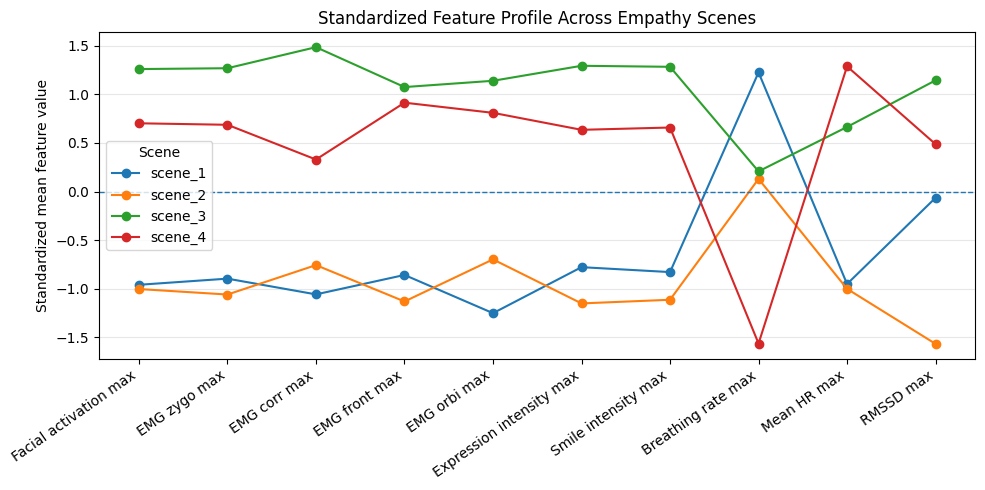

In [40]:
# Standardized scene-level feature profile

profile_features = [
    "facialactivation_facialactivation_max",
    "emgactivation_emg_amplitude_zygo_weighted_max",
    "emgactivation_emg_amplitude_corr_weighted_max",
    "emgactivation_emg_amplitude_front_weighted_max",
    "emgactivation_emg_amplitude_orbi_weighted_max",
    "expression_expression_intensity_max",
    "expression_smile_intensity_max",
    "breathingrate_breathingrate_max",
    "hrv_hrv_mean_hr_max",
    "hrv_hrv_rmssd_max",
]

profile_features = [col for col in profile_features if col in df.columns]

scene_means = df.groupby("scene_name")[profile_features].mean().loc[scene_order]

# z-score across scenes for each feature, so different feature scales become comparable
scene_profile_z = (scene_means - scene_means.mean()) / scene_means.std(ddof=0)

display(scene_profile_z)

plt.figure(figsize=(10, 5))

for scene in scene_profile_z.index:
    plt.plot(
        [clean_feature_label(col) for col in profile_features],
        scene_profile_z.loc[scene],
        marker="o",
        label=scene.replace("empathy_", "")
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.ylabel("Standardized mean feature value")
plt.title("Standardized Feature Profile Across Empathy Scenes")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Scene")
plt.tight_layout()
plt.show()

The scene level feature analysis shows that the four empathy scenes differ not only in self reported ratings, but also in the extracted sensor derived features. The clearest differences are observed in facial activation, EMG activation and expression intensity features.

Empathy scenes 3 and 4 show the highest facial activation and EMG related maximum values. Scene 3 has the highest facial activation maximum, zygomaticus activation maximum, orbicularis activation maximum, overall expression intensity maximum and smile intensity maximum. This is particularly interesting because scene 3 was previously characterized by lower self reported valence, arousal and discomfort. This suggests that sensor derived facial responses do not always map directly onto the subjective rating intensity and may also reflect scene specific facial behavior or contextual responses.

Scene 4 also shows high facial and EMG activation, especially in frontal and orbicularis activation, and relatively high expression intensity. In contrast, scenes 1 and 2 show lower facial and expression related activation overall.

Physiological features such as breathing rate and heart rate appear more stable across scenes compared with the facial and expression- elated features. This suggests that the strongest scene level differences in the current dataset are mainly present in the facial and expression modalities.

Overall, this analysis shows that scene identity is an important factor in the dataset. Later analyses that compare features across valence, arousal or discomfort categories should therefore be interpreted carefully, because some feature differences may reflect scene specific effects rather than only the self reported emotional categories.


## Facial and Expression Features Across Valence Categories

After inspecting scene level feature patterns, the next step is to explore whether facial and expression related features differ across self reported valence categories. Previous affective sensing work suggests that positive valence is often associated with stronger cheek or zygomaticus activation, while negative valence may be associated with stronger brow or corrugator related activation.

In this dataset, valence was grouped into low, medium and high categories. This section compares selected facial activation, EMG activation and expression intensity features across these valence categories. The goal is to identify whether higher or lower self reported valence is reflected in the extracted facial and expression features.


In [41]:
valence_features = [
    "facialactivation_facialactivation_max",
    "emgactivation_emg_amplitude_zygo_weighted_max",
    "emgactivation_emg_amplitude_corr_weighted_max",
    "emgactivation_emg_amplitude_front_weighted_max",
    "emgactivation_emg_amplitude_orbi_weighted_max",
    "expression_expression_intensity_max",
    "expression_smile_intensity_max",
    "expression_frown_intensity_max",
    "expression_eyebrow_raise_intensity_max",
]

valence_features = [col for col in valence_features if col in df.columns]

display(pd.DataFrame({"valence_feature": valence_features}))

,valence_feature
0,facialactivation_facialactivation_max
1,emgactivation_emg_amplitude_zygo_weighted_max
2,emgactivation_emg_amplitude_corr_weighted_max
3,emgactivation_emg_amplitude_front_weighted_max
4,emgactivation_emg_amplitude_orbi_weighted_max
5,expression_expression_intensity_max
6,expression_smile_intensity_max
7,expression_frown_intensity_max
8,expression_eyebrow_raise_intensity_max


/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1449630705.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


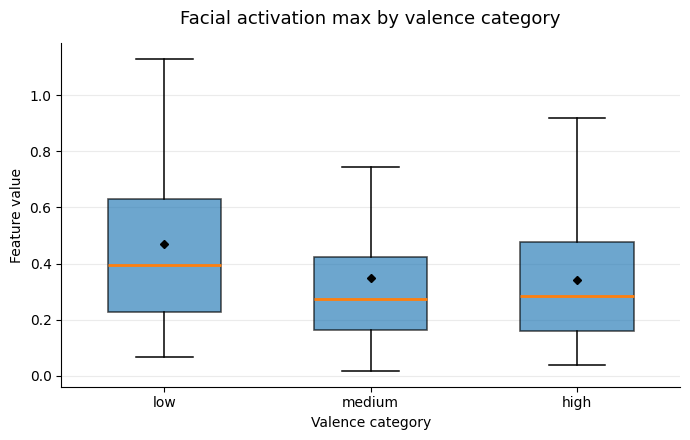

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1449630705.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


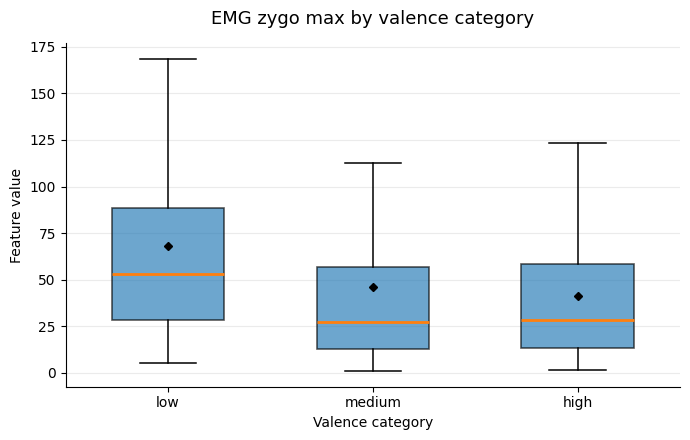

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1449630705.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


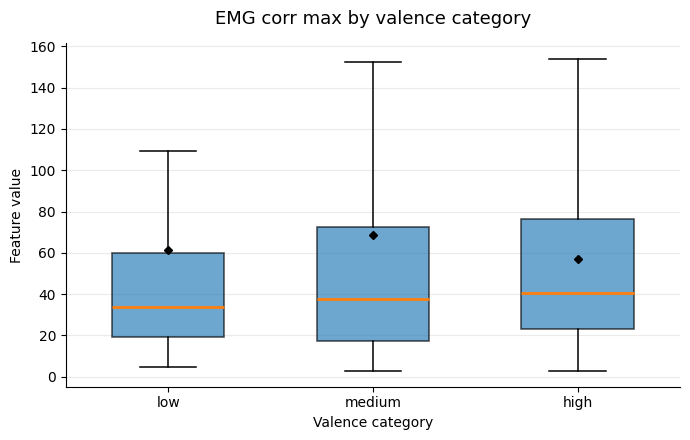

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1449630705.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


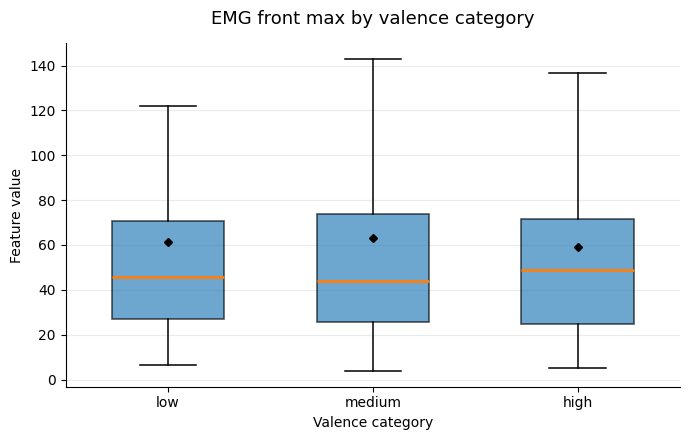

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1449630705.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


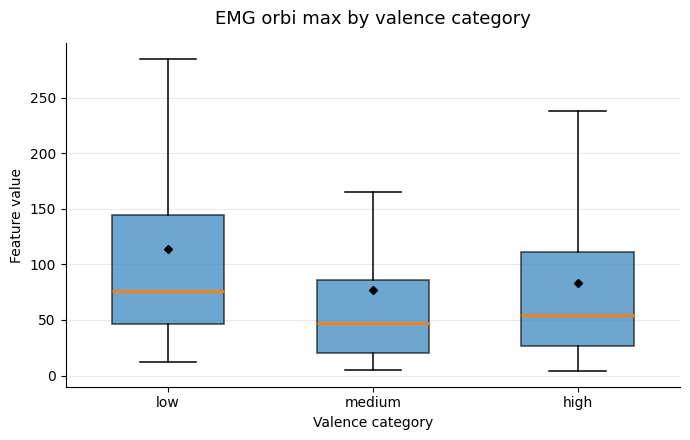

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1449630705.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


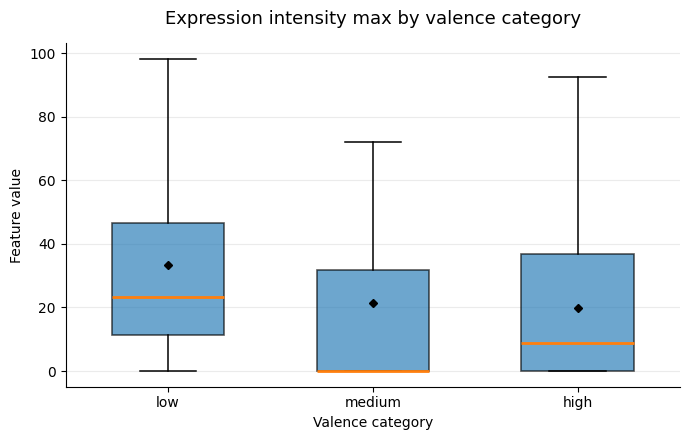

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1449630705.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


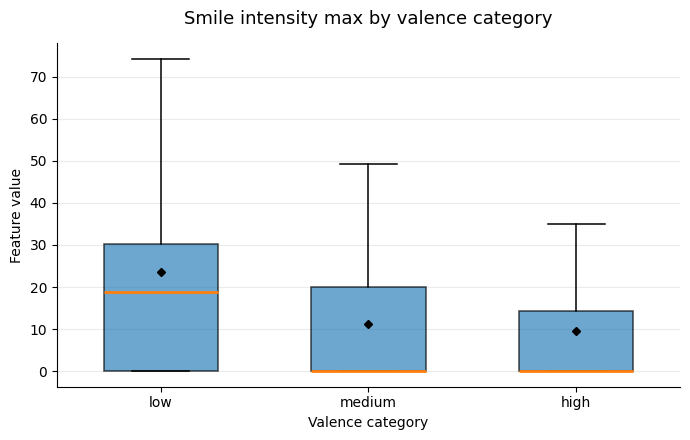

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1449630705.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


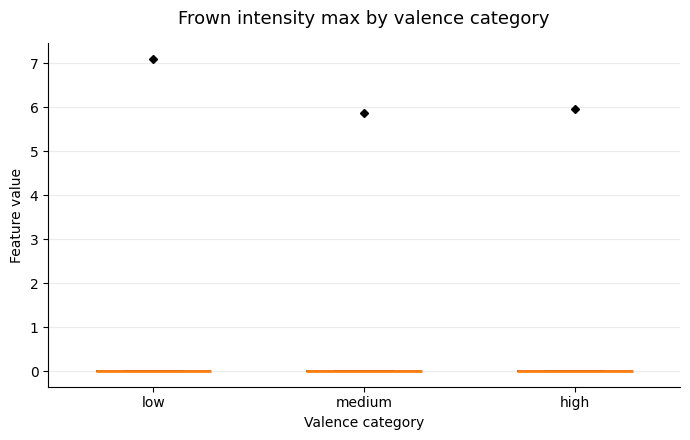

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1449630705.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


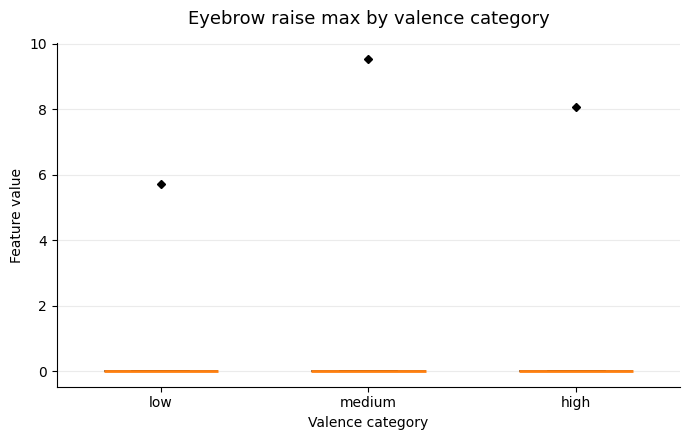

In [42]:
category_order = ["low", "medium", "high"]

for feature in valence_features:
    plot_data = [
        df.loc[df["valence_category"] == category, feature].dropna()
        for category in category_order
    ]

    plt.figure(figsize=(7, 4.5))

    box = plt.boxplot(
        plot_data,
        labels=category_order,
        patch_artist=True,
        showmeans=True,
        showfliers=False,
        widths=0.55,
        medianprops={"linewidth": 2},
        meanprops={
            "marker": "D",
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markersize": 4,
        },
        boxprops={"linewidth": 1.2},
        whiskerprops={"linewidth": 1.1},
        capprops={"linewidth": 1.1},
    )

    for patch in box["boxes"]:
        patch.set_alpha(0.65)

    plt.title(f"{clean_feature_label(feature)} by valence category", fontsize=13, pad=14)
    plt.xlabel("Valence category")
    plt.ylabel("Feature value")
    plt.grid(axis="y", alpha=0.25)

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

In [43]:
valence_feature_summary = (
    df.groupby("valence_category")[valence_features]
    .agg(["mean", "median", "std"])
    .reindex(category_order)
)

display(valence_feature_summary)

facialactivation_facialactivation_max                      \
                                                  mean    median       std   
valence_category                                                             
low                                           0.470723  0.393347  0.329086   
medium                                        0.348958  0.272154  0.283596   
high                                          0.340965  0.285564  0.232193   

                 emgactivation_emg_amplitude_zygo_weighted_max             \
                                                          mean     median   
valence_category                                                            
low                                                  67.962354  52.864580   
medium                                               45.990237  27.213233   
high                                                 41.037593  28.220637   

                            emgactivation_emg_amplitude_corr_weighted_max  \
                        std                                          mean   
valence_category                                                            
low               50.655117                                     61.449119   
medium            53.393696                                     68.507501   
high              35.520114                                     56.783247   

                                         \
                     median         std   
valence_category                          
low               33.622358   94.077368   
medium            37.660764  130.808958   
high              40.332071   51.280738   

                 emgactivation_emg_amplitude_front_weighted_max             \
                                                           mean     median   
valence_category                                                             
low                                                   61.345765  45.839945   
medium                                                62.939544  43.737965   
high                                                  59.023576  48.776046   

                            emgactivation_emg_amplitude_orbi_weighted_max  \
                        std                                          mean   
valence_category                                                            
low               55.012945                                    114.009250   
medium            58.752103                                     76.927062   
high              51.775716                                     83.410978   

                                        expression_expression_intensity_max  \
                     median         std                                mean   
valence_category                                                              
low               76.487761  107.463054                           33.288636   
medium            46.947147   96.258503                           21.335366   
high              54.238945   88.947830                           19.966822   

                                   expression_smile_intensity_max         \
                 median        std                           mean median   
valence_category                                                           
low                23.4  35.545679                      23.473864  18.85   
medium              0.0  31.457160                      11.258537   0.00   
high                8.7  25.493604                       9.649533   0.00   

                            expression_frown_intensity_max                    \
                        std                           mean median        std   
valence_category                                                               
low               26.072095                       7.093182    0.0  29.912369   
medium            20.753830                       5.859756    0.0  21.043276   
high              17.285780                       5.952336    0.0  16.686312   

                 e

,facialactivation_facialactivation_max,emgactivation_emg_amplitude_zygo_weighted_max,emgactivation_emg_amplitude_corr_weighted_max,emgactivation_emg_amplitude_front_weighted_max,emgactivation_emg_amplitude_orbi_weighted_max,expression_expression_intensity_max,expression_smile_intensity_max,expression_frown_intensity_max,expression_eyebrow_raise_intensity_max
valence_category,,,,,,,,,
low,1.412076,1.392940,-0.165474,0.151008,1.395137,1.408035,1.406183,1.410999,-1.307959
medium,-0.638731,-0.484839,1.299069,1.142238,-0.898054,-0.589658,-0.572758,-0.788029,1.119740
high,-0.773345,-0.908101,-1.133595,-1.293247,-0.497083,-0.818377,-0.833425,-0.622971,0.188219


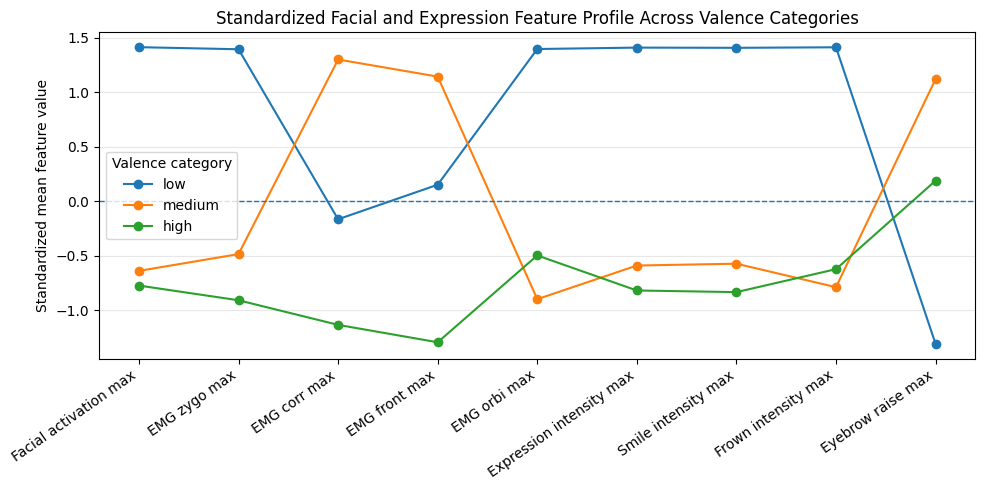

In [44]:
valence_means = df.groupby("valence_category")[valence_features].mean().reindex(category_order)

# z-score across valence categories for each feature
valence_profile_z = (valence_means - valence_means.mean()) / valence_means.std(ddof=0)

display(valence_profile_z)

plt.figure(figsize=(10, 5))

for category in valence_profile_z.index:
    plt.plot(
        [clean_feature_label(col) for col in valence_features],
        valence_profile_z.loc[category],
        marker="o",
        label=category
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.ylabel("Standardized mean feature value")
plt.title("Standardized Facial and Expression Feature Profile Across Valence Categories")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Valence category")
plt.tight_layout()
plt.show()

The valence based feature analysis shows that facial and expression related features do not follow a simple positive valence activation pattern in this dataset. Contrary to the expectation that higher valence would be associated with stronger zygomaticus or smile related activation, the low valence category shows the highest standardized values for facial activation, zygomaticus activation, orbicularis activation, overall expression intensity and smile intensity.

This pattern is important because the earlier scene level analysis showed that empathy scene 3 was characterized by low self reported valence, arousal and discomfort, but relatively high facial and expression related activation. Therefore, the elevated activation observed in the low valence category may partly reflect scene specific facial behavior rather than valence alone.

The corrugator and frontal EMG features do not show a clear monotonic trend across valence categories. Corrugator activation is higher in the medium and high valence categories compared with low valence, while frontal activation is relatively similar across categories. Frown and eyebrow raise intensity features remain close to zero for most samples, suggesting that these specific expressions were rarely detected with substantial intensity.

Overall, these results suggest that valence related facial responses in this dataset are context-dependent. The relationship between self reported valence and facial activation is not straightforward, and later statistical or machine learning analyses should account for possible scene effects.


## Facial, Physiological and Motion Features Across Arousal Categories

After examining valence related patterns, the next step is to explore how the extracted features vary across self reported arousal categories. Arousal reflects the intensity of the emotional response, so it may be associated not only with facial and expression related activation, but also with physiological and motion related features.

Previous optomyography based work found that higher self reported arousal was associated with increased activation across facial muscle regions. In this dataset, the analysis is extended by also inspecting breathing rate, HRV and motion related features.


In [45]:
arousal_features = [
    # Facial / EMG activation
    "facialactivation_facialactivation_max",
    "emgactivation_emg_amplitude_zygo_weighted_max",
    "emgactivation_emg_amplitude_corr_weighted_max",
    "emgactivation_emg_amplitude_front_weighted_max",
    "emgactivation_emg_amplitude_orbi_weighted_max",

    # Expressions
    "expression_expression_intensity_max",
    "expression_smile_intensity_max",

    # Physiological / motion
    "breathingrate_breathingrate_max",
    "hrv_hrv_mean_hr_max",
    "hrv_hrv_rmssd_max",
    "hrv_imu_motionintensity_max",
]

arousal_features = [col for col in arousal_features if col in df.columns]

display(pd.DataFrame({"arousal_feature": arousal_features}))

,arousal_feature
0,facialactivation_facialactivation_max
1,emgactivation_emg_amplitude_zygo_weighted_max
2,emgactivation_emg_amplitude_corr_weighted_max
3,emgactivation_emg_amplitude_front_weighted_max
4,emgactivation_emg_amplitude_orbi_weighted_max
5,expression_expression_intensity_max
6,expression_smile_intensity_max
7,breathingrate_breathingrate_max
8,hrv_hrv_mean_hr_max
9,hrv_hrv_rmssd_max


/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1759649532.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


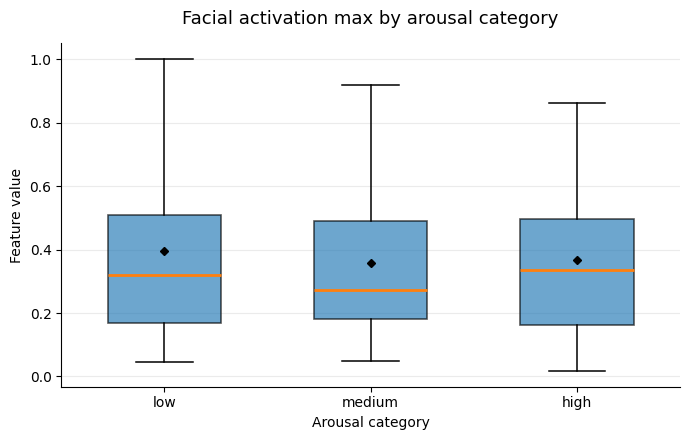

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1759649532.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


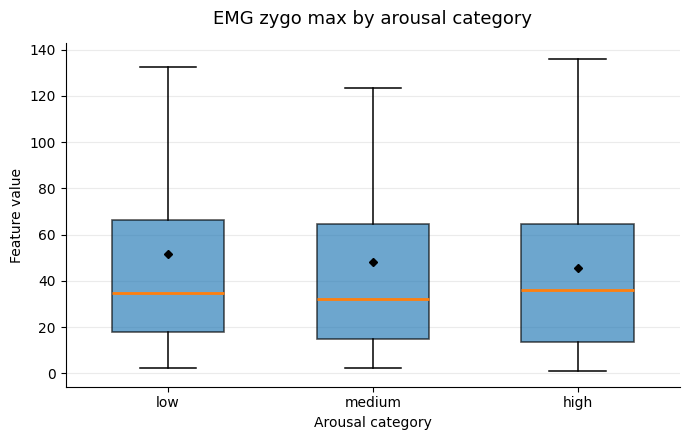

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1759649532.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


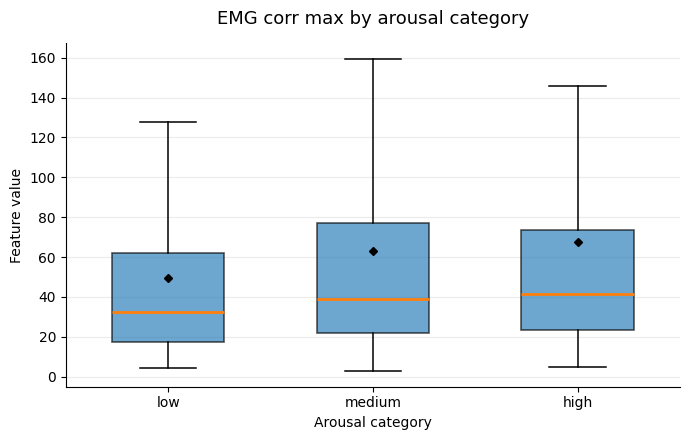

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1759649532.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


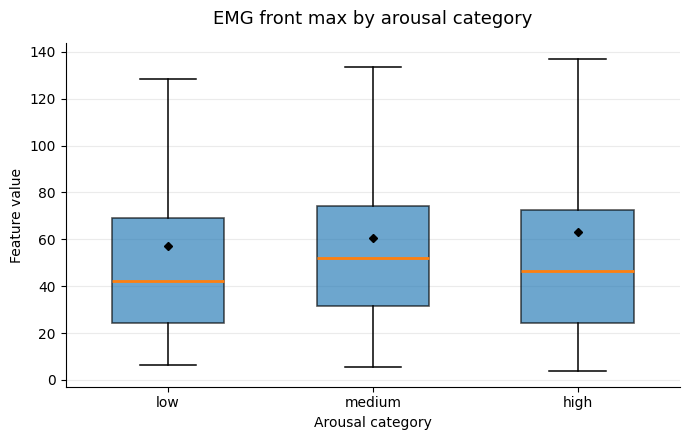

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1759649532.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


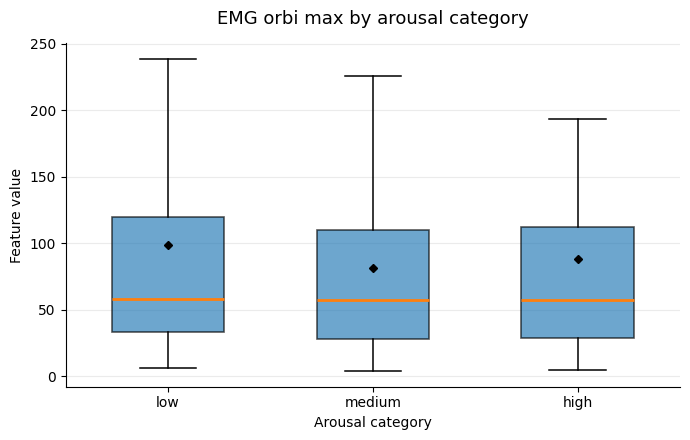

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1759649532.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


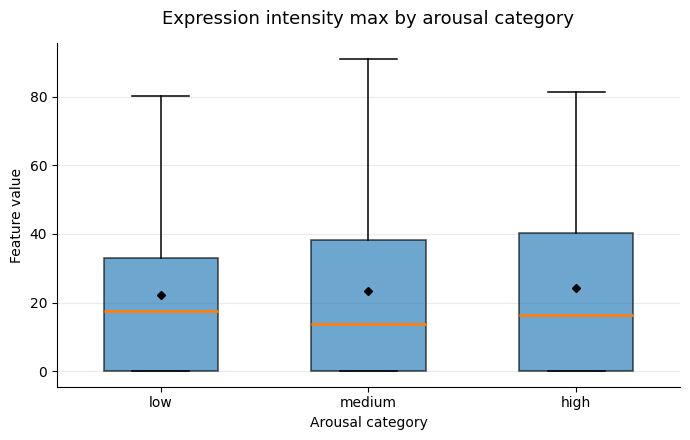

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1759649532.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


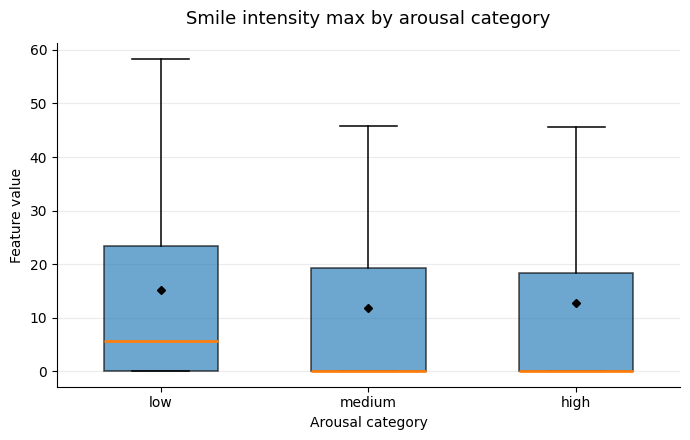

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1759649532.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


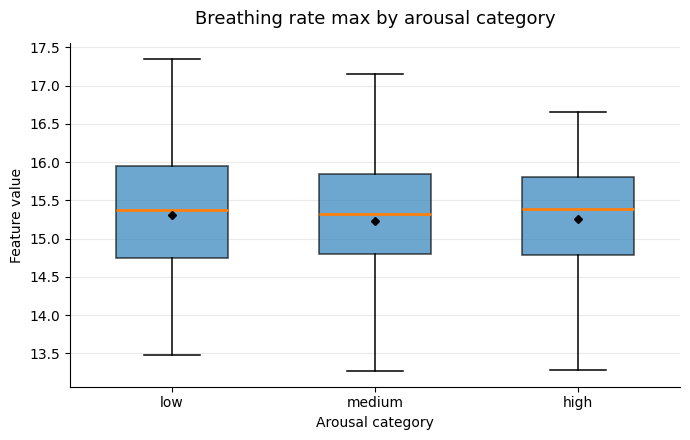

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1759649532.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


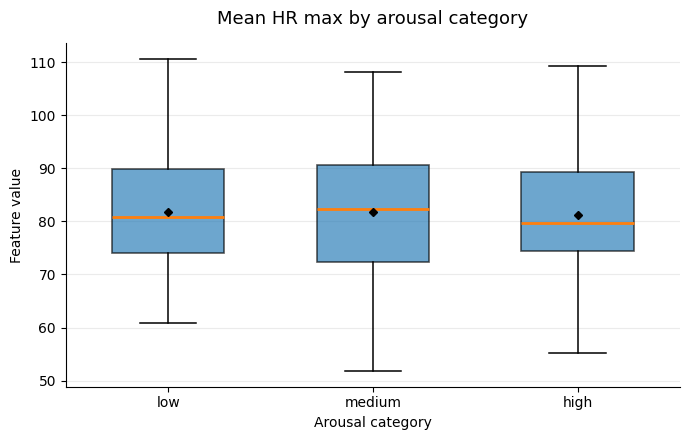

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1759649532.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


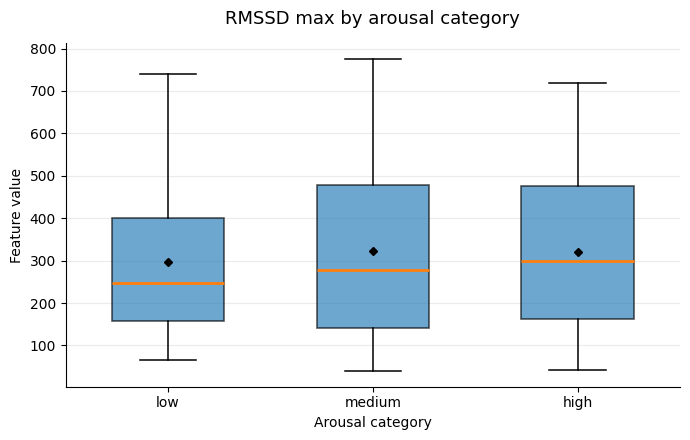

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1759649532.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


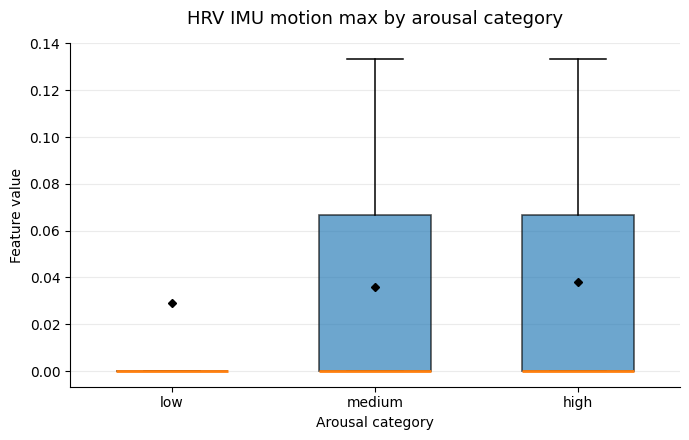

In [46]:
category_order = ["low", "medium", "high"]

for feature in arousal_features:
    plot_data = [
        df.loc[df["arousal_category"] == category, feature].dropna()
        for category in category_order
    ]

    plt.figure(figsize=(7, 4.5))

    box = plt.boxplot(
        plot_data,
        labels=category_order,
        patch_artist=True,
        showmeans=True,
        showfliers=False,
        widths=0.55,
        medianprops={"linewidth": 2},
        meanprops={
            "marker": "D",
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markersize": 4,
        },
        boxprops={"linewidth": 1.2},
        whiskerprops={"linewidth": 1.1},
        capprops={"linewidth": 1.1},
    )

    for patch in box["boxes"]:
        patch.set_alpha(0.65)

    plt.title(f"{clean_feature_label(feature)} by arousal category", fontsize=13, pad=14)
    plt.xlabel("Arousal category")
    plt.ylabel("Feature value")
    plt.grid(axis="y", alpha=0.25)

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

,facialactivation_facialactivation_max,emgactivation_emg_amplitude_zygo_weighted_max,emgactivation_emg_amplitude_corr_weighted_max,emgactivation_emg_amplitude_front_weighted_max,emgactivation_emg_amplitude_orbi_weighted_max,expression_expression_intensity_max,expression_smile_intensity_max,breathingrate_breathingrate_max,hrv_hrv_mean_hr_max,hrv_hrv_rmssd_max,hrv_imu_motionintensity_max
arousal_category,,,,,,,,,,,
low,1.375494,1.302762,-1.368894,-1.283992,1.303819,-1.214894,1.371139,1.376497,0.755239,-1.412035,-1.388382
medium,-0.972373,-0.174822,0.376880,0.128650,-1.126295,-0.019469,-0.985542,-0.969213,0.657857,0.773973,0.461173
high,-0.403121,-1.127940,0.992014,1.155342,-0.177524,1.234363,-0.385597,-0.407284,-1.413096,0.638062,0.927209


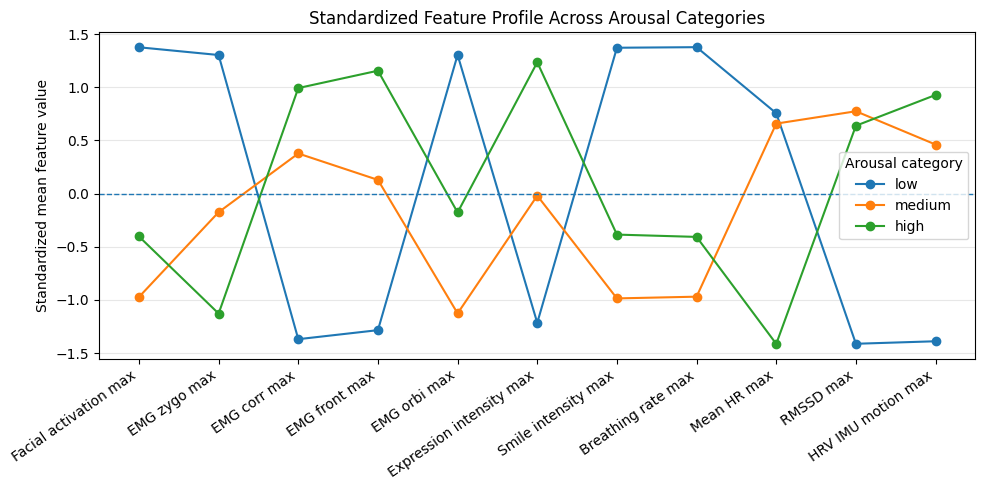

In [47]:
arousal_means = df.groupby("arousal_category")[arousal_features].mean().reindex(category_order)

arousal_profile_z = (arousal_means - arousal_means.mean()) / arousal_means.std(ddof=0)

display(arousal_profile_z)

plt.figure(figsize=(10, 5))

for category in arousal_profile_z.index:
    plt.plot(
        [clean_feature_label(col) for col in arousal_features],
        arousal_profile_z.loc[category],
        marker="o",
        label=category
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.ylabel("Standardized mean feature value")
plt.title("Standardized Feature Profile Across Arousal Categories")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Arousal category")
plt.tight_layout()
plt.show()

The arousal based feature analysis shows that the relationship between self reported arousal and sensor derived features is not strictly monotonic. Although high arousal is expected to reflect stronger emotional intensity, most facial and expression related features do not show a simple increase from low to medium to high arousal.

Facial activation, zygomaticus activation, overall expression intensity and smile intensity are relatively similar across arousal categories. In the standardized profile, the low arousal category shows higher values for several facial and smile related features. This may reflect the previously observed scene-level effect, especially because empathy scene 3 was characterized by low self-reported arousal but relatively high facial and expression related activation.

Some features show a pattern more consistent with increased arousal. Corrugator and frontal EMG activation are higher in the high-arousal category, suggesting that these facial muscle regions may be more responsive to emotionally intense or more cognitively engaging scenes. HRV related and motion related features also appear somewhat higher in the medium and high arousal categories compared with low arousal.

Overall, the arousal analysis suggests that self reported arousal is related to some sensor derived features, but the relationship is not uniform across modalities. Scene effects and individual response differences likely influence the observed patterns. Therefore, later statistical and machine learning analyses should consider that arousal related responses may be distributed across facial, physiological and motion features rather than captured by a single activation measure.


## Facial, Physiological and Motion Features Across Discomfort Categories

In addition to valence and arousal, the dataset contains self reported discomfort ratings. Discomfort is explored as an additional affective response measure because it may capture emotional tension or unpleasant engagement with the empathy scenes.

Previous sections showed that discomfort is positively related to both valence and arousal in this dataset. This section examines whether discomfort categories are reflected in facial activation, expression intensity, physiological features and motion-related features.


In [48]:
discomfort_features = [
    # Facial / EMG activation
    "facialactivation_facialactivation_max",
    "emgactivation_emg_amplitude_zygo_weighted_max",
    "emgactivation_emg_amplitude_corr_weighted_max",
    "emgactivation_emg_amplitude_front_weighted_max",
    "emgactivation_emg_amplitude_orbi_weighted_max",

    # Expressions
    "expression_expression_intensity_max",
    "expression_smile_intensity_max",

    # Physiological / motion
    "breathingrate_breathingrate_max",
    "hrv_hrv_mean_hr_max",
    "hrv_hrv_rmssd_max",
    "hrv_imu_motionintensity_max",
]

discomfort_features = [col for col in discomfort_features if col in df.columns]

display(pd.DataFrame({"discomfort_feature": discomfort_features}))

,discomfort_feature
0,facialactivation_facialactivation_max
1,emgactivation_emg_amplitude_zygo_weighted_max
2,emgactivation_emg_amplitude_corr_weighted_max
3,emgactivation_emg_amplitude_front_weighted_max
4,emgactivation_emg_amplitude_orbi_weighted_max
5,expression_expression_intensity_max
6,expression_smile_intensity_max
7,breathingrate_breathingrate_max
8,hrv_hrv_mean_hr_max
9,hrv_hrv_rmssd_max


/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1719870065.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


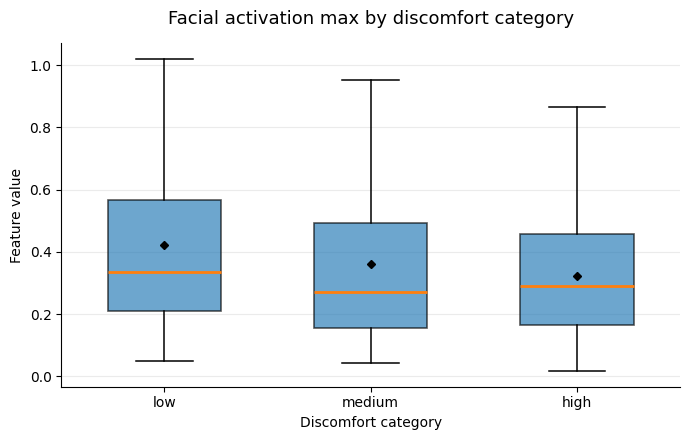

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1719870065.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


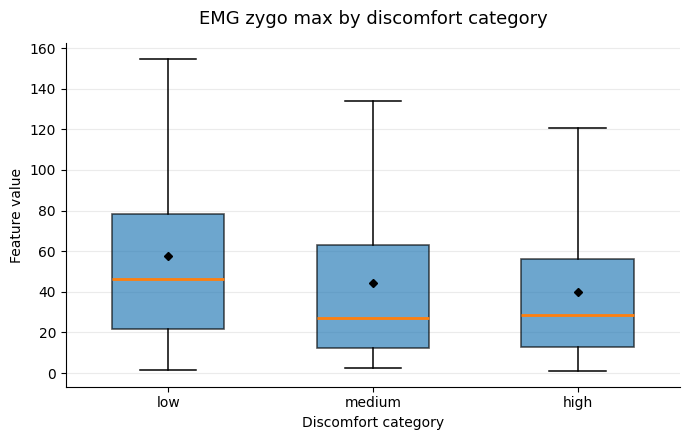

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1719870065.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


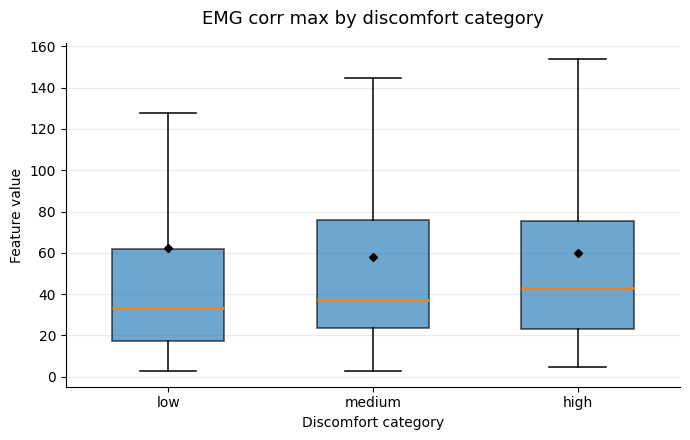

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1719870065.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


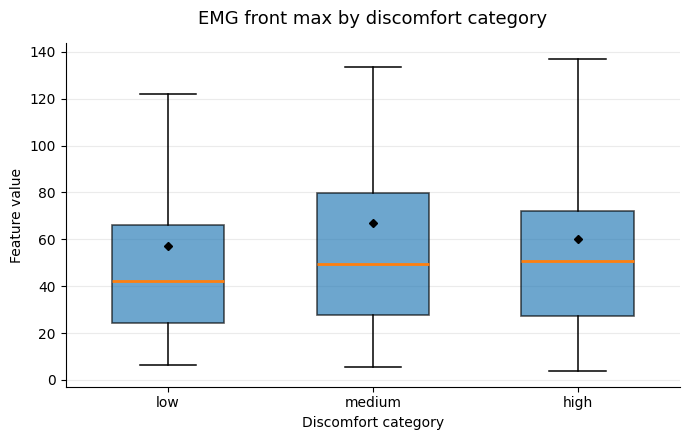

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1719870065.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


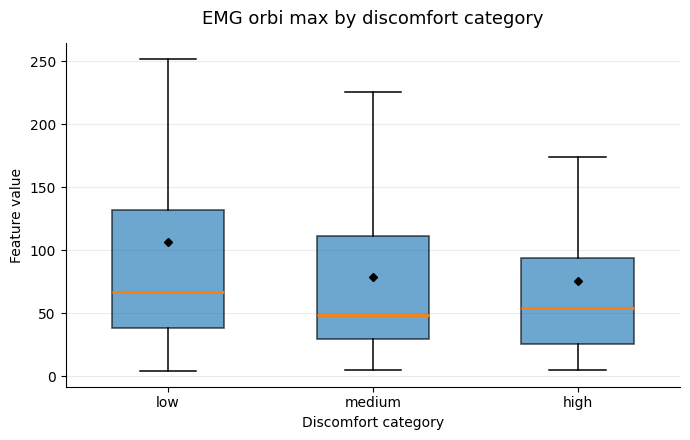

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1719870065.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


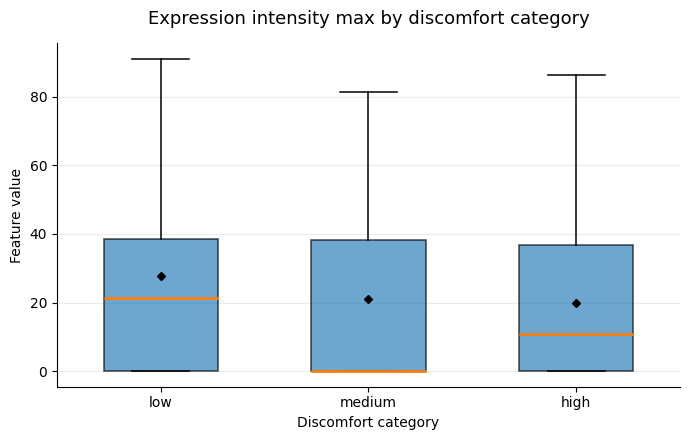

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1719870065.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


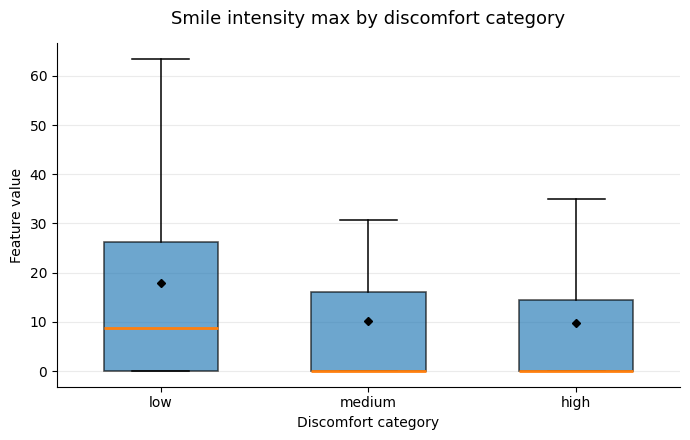

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1719870065.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


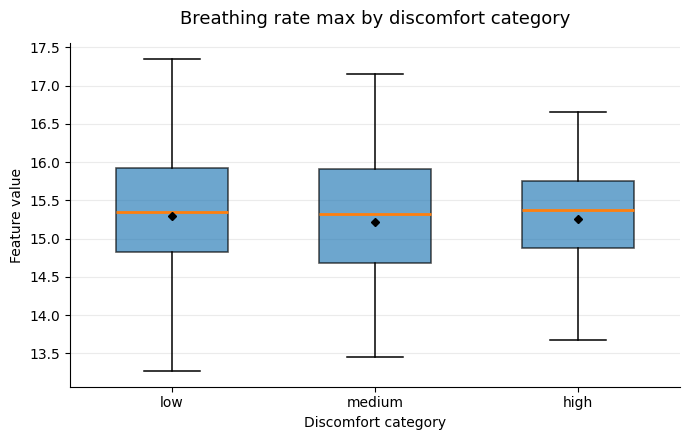

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1719870065.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


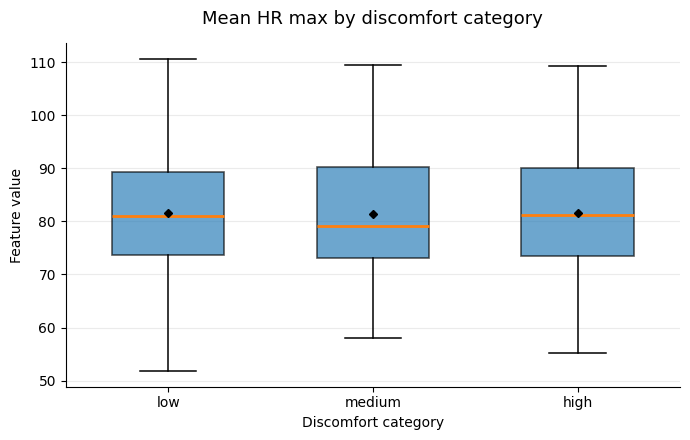

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1719870065.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


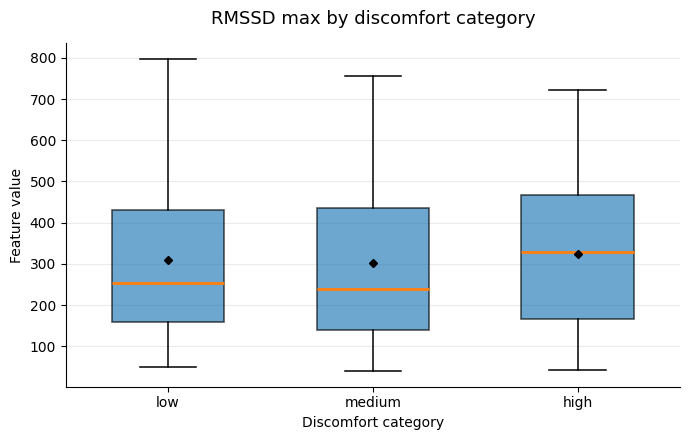

/var/folders/hw/r37654mx6xv14qs_s2nq_j_00000gn/T/ipykernel_1728/1719870065.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


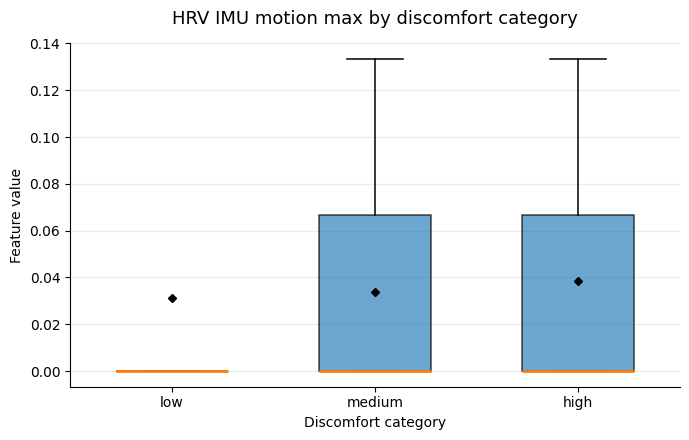

In [49]:
category_order = ["low", "medium", "high"]

for feature in discomfort_features:
    plot_data = [
        df.loc[df["discomfort_category"] == category, feature].dropna()
        for category in category_order
    ]

    plt.figure(figsize=(7, 4.5))

    box = plt.boxplot(
        plot_data,
        labels=category_order,
        patch_artist=True,
        showmeans=True,
        showfliers=False,
        widths=0.55,
        medianprops={"linewidth": 2},
        meanprops={
            "marker": "D",
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markersize": 4,
        },
        boxprops={"linewidth": 1.2},
        whiskerprops={"linewidth": 1.1},
        capprops={"linewidth": 1.1},
    )

    for patch in box["boxes"]:
        patch.set_alpha(0.65)

    plt.title(f"{clean_feature_label(feature)} by discomfort category", fontsize=13, pad=14)
    plt.xlabel("Discomfort category")
    plt.ylabel("Feature value")
    plt.grid(axis="y", alpha=0.25)

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

,facialactivation_facialactivation_max,emgactivation_emg_amplitude_zygo_weighted_max,emgactivation_emg_amplitude_corr_weighted_max,emgactivation_emg_amplitude_front_weighted_max,emgactivation_emg_amplitude_orbi_weighted_max,expression_expression_intensity_max,expression_smile_intensity_max,breathingrate_breathingrate_max,hrv_hrv_mean_hr_max,hrv_hrv_rmssd_max,hrv_imu_motionintensity_max
discomfort_category,,,,,,,,,,,
low,1.310055,1.369409,1.268298,-1.022544,1.406366,1.400000,1.413137,1.234101,0.617422,-0.335076,-1.056144
medium,-0.193706,-0.378863,-1.175965,1.357323,-0.574340,-0.526796,-0.658787,-1.215169,-1.410570,-1.022333,-0.286434
high,-1.116348,-0.990546,-0.092333,-0.334779,-0.832027,-0.873204,-0.754350,-0.018932,0.793148,1.357409,1.342578


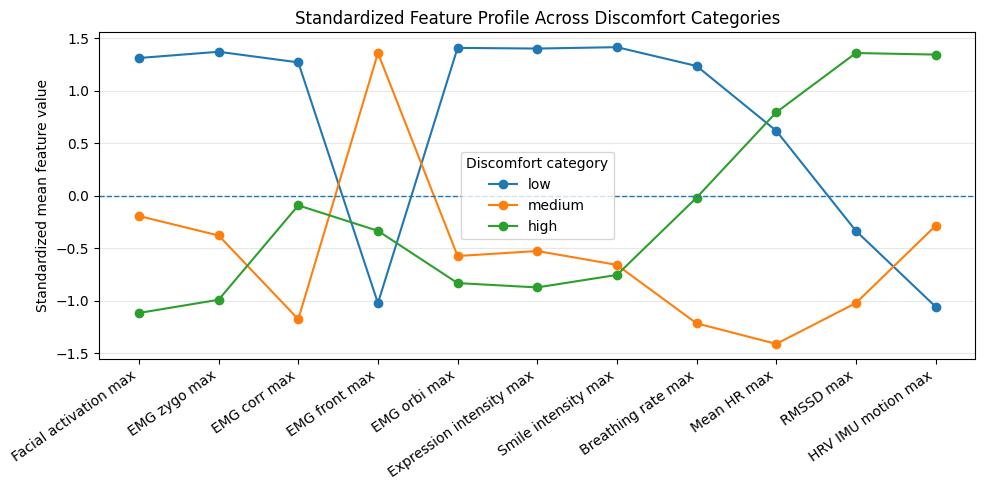

In [50]:
discomfort_means = (
    df.groupby("discomfort_category")[discomfort_features]
    .mean()
    .reindex(category_order)
)

discomfort_profile_z = (
    discomfort_means - discomfort_means.mean()
) / discomfort_means.std(ddof=0)

display(discomfort_profile_z)

plt.figure(figsize=(10, 5))

for category in discomfort_profile_z.index:
    plt.plot(
        [clean_feature_label(col) for col in discomfort_features],
        discomfort_profile_z.loc[category],
        marker="o",
        label=category
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.ylabel("Standardized mean feature value")
plt.title("Standardized Feature Profile Across Discomfort Categories")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Discomfort category")
plt.tight_layout()
plt.show()

The discomfort based feature analysis shows that discomfort is reflected differently across feature groups. Facial activation, zygomaticus activation, orbicularis activation, overall expression intensity and smile intensity are highest in the low discomfort category. This pattern is consistent with the earlier scene level analysis, where empathy scene 3 showed low self-reported discomfort but relatively high facial and expression related activation.

This suggests that facial activation in the current dataset is not simply a marker of discomfort intensity. Instead, it may reflect scene specific facial behavior or the type of emotional response elicited by a particular scene. Therefore, higher facial activation should not be interpreted directly as higher discomfort without considering scene context.

Some physiological and motion related features show a different pattern. RMSSD and HRV related motion intensity are higher in the high discomfort category compared with low discomfort. Mean heart rate remains relatively stable across discomfort categories, while breathing rate does not show a strong visual separation.

Overall, discomfort appears to be related to some physiological and motion related features, while facial and expression-related features are strongly influenced by scene level patterns. This reinforces the need to interpret valence, arousal and discomfort together with scene identity in the following analyses.


## Feature Target Correlation Analysis

To summarize the relationship between the extracted features and the self reported targets, Spearman correlations are computed between each sensor derived feature and the three affective ratings: valence, arousal and discomfort. Spearman correlation is used because the target ratings are ordinal and discrete.

This analysis provides an overview of which features show the strongest monotonic relationship with each affective target. The results should be interpreted as exploratory, since previous sections showed that scene identity may influence both self reported ratings and sensor derived features.


,target_valence,target_arousal,target_discomfort
expression_smile_intensity_max,-0.232063,-0.082790,-0.220097
expression_smile_intensity_min,-0.225254,-0.058970,-0.199345
emgactivation_emg_amplitude_zygo_weighted_max,-0.170341,-0.051828,-0.183738
emgactivation_emg_amplitude_orbi_weighted_max,-0.113509,-0.014838,-0.154214
facialactivation_facialactivation_max,-0.112067,-0.011747,-0.137482
emgactivation_emg_amplitude_corr_weighted_min,0.136461,0.037482,0.079265
emgactivation_emg_amplitude_front_weighted_min,0.134607,0.076724,0.130623
expression_expression_intensity_max,-0.112617,-0.003506,-0.133488
breathingrate_breathingrate_min,0.029968,-0.031297,0.100288
emgactivation_emg_amplitude_corr_weighted_max,0.090173,0.098655,0.091916


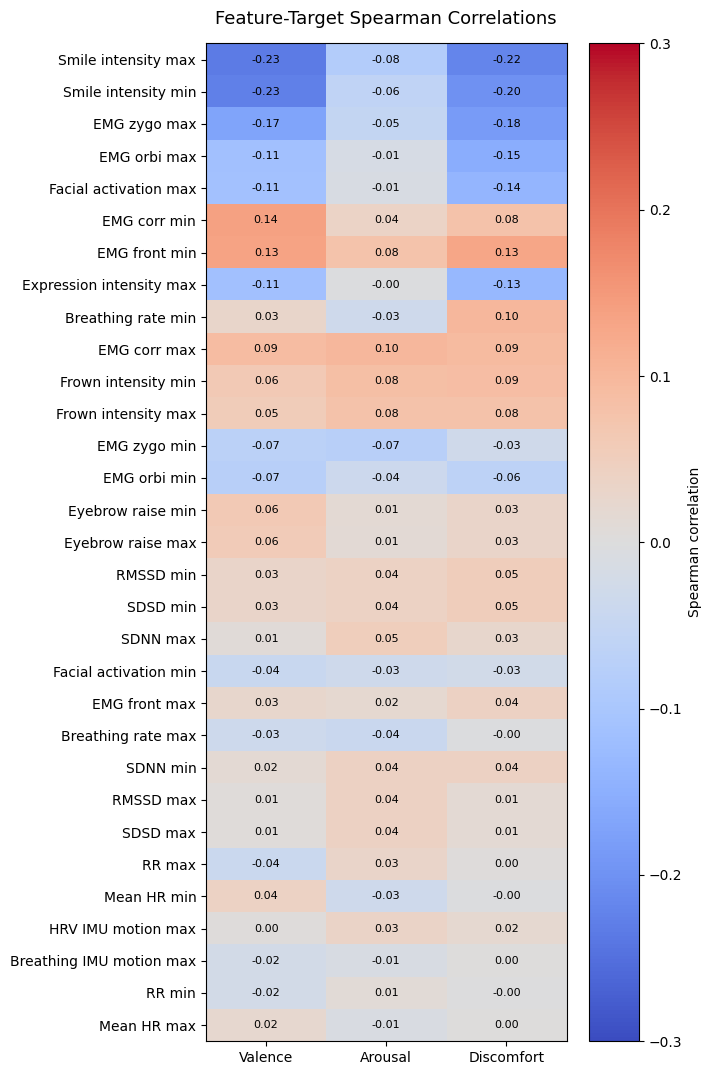

In [52]:
# Remove features with undefined correlations
feature_target_corr_clean = feature_target_corr.dropna(how="all")

# Sort by strongest absolute correlation
feature_order = (
    feature_target_corr_clean
    .abs()
    .max(axis=1)
    .sort_values(ascending=False)
    .index
)

feature_target_corr_sorted = feature_target_corr_clean.loc[feature_order]

display(feature_target_corr_sorted)

feature_labels = [
    clean_feature_label(feature)
    for feature in feature_target_corr_sorted.index
]

target_labels = [
    col.replace("target_", "").capitalize()
    for col in feature_target_corr_sorted.columns
]

# Use tighter color limits because observed correlations are small
max_abs_corr = feature_target_corr_sorted.abs().max().max()
color_limit = max(0.25, np.ceil(max_abs_corr * 10) / 10)

plt.figure(figsize=(7, max(7, len(feature_target_corr_sorted) * 0.35)))

im = plt.imshow(
    feature_target_corr_sorted.values,
    vmin=-color_limit,
    vmax=color_limit,
    aspect="auto",
    cmap="coolwarm"
)

plt.colorbar(im, label="Spearman correlation")

plt.xticks(
    ticks=np.arange(len(target_labels)),
    labels=target_labels
)

plt.yticks(
    ticks=np.arange(len(feature_labels)),
    labels=feature_labels
)

plt.title("Feature-Target Spearman Correlations", fontsize=13, pad=14)

for i in range(feature_target_corr_sorted.shape[0]):
    for j in range(feature_target_corr_sorted.shape[1]):
        value = feature_target_corr_sorted.iloc[i, j]
        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.show()

The feature target correlation analysis shows that the relationships between individual sensor derived features and the self reported targets are generally weak. Most Spearman correlation coefficients are close to zero, indicating that no single feature has a strong monotonic relationship with valence, arousal or discomfort across the full dataset.

The strongest correlations are observed for smile intensity, zygomaticus activation, orbicularis activation and facial activation, but these relationships are negative and relatively small. Smile intensity shows the strongest negative association with valence and discomfort, while zygomaticus and orbicularis activation also show weak negative associations with the targets. This is consistent with the earlier category based analyses, where lower valence and lower discomfort were associated with higher facial and smile related activation.

Arousal shows particularly weak correlations with individual features. This suggests that arousal related responses may not be captured by a single feature, but may instead depend on a combination of facial, physiological and motion related features.

Some features have undefined correlations because their values are constant or nearly constant across the dataset. These features do not provide useful information for correlation based interpretation and were excluded from the cleaned heatmap.

Overall, the correlation results reinforce the conclusion that the relationship between sensor features and self reported affect is not simple or linear. Scene identity and individual variability likely play an important role, so later statistical and machine learning analyses should consider multivariate patterns rather than relying on individual features alone.


## Scene adjusted Feature Target Correlations

The previous analyses showed that scene identity strongly influences both self reported ratings and sensor derived features. Because of this, simple feature target correlations may partly reflect differences between empathy scenes rather than direct relationships between sensor responses and affective ratings.

To explore this, a scene adjusted correlation analysis is performed. For each feature and target variable, the scene level mean is subtracted from each sample. This produces scene centered values that describe whether a sample is above or below the average response for that specific scene. Correlations are then computed on these scene adjusted values.

This analysis helps determine whether feature target relationships remain visible after reducing the influence of scene level effects.


,Valence,Arousal,Discomfort
expression_frown_intensity_max,0.139138,0.012425,0.014456
expression_frown_intensity_min,0.076414,0.114890,0.109971
breathingrate_breathingrate_min,0.028769,-0.047738,0.106904
expression_expression_intensity_max,0.025043,0.106031,0.033808
hrv_hrv_sdnn_max,0.047452,0.088816,0.100451
expression_eyebrow_raise_intensity_min,0.099006,0.040171,0.083043
hrv_hrv_rmssd_min,0.064340,0.055337,0.097644
hrv_hrv_sdsd_min,0.064235,0.055131,0.097545
hrv_hrv_sdnn_min,0.045285,0.067163,0.088002
hrv_hrv_rmssd_max,0.045391,0.080681,0.087614


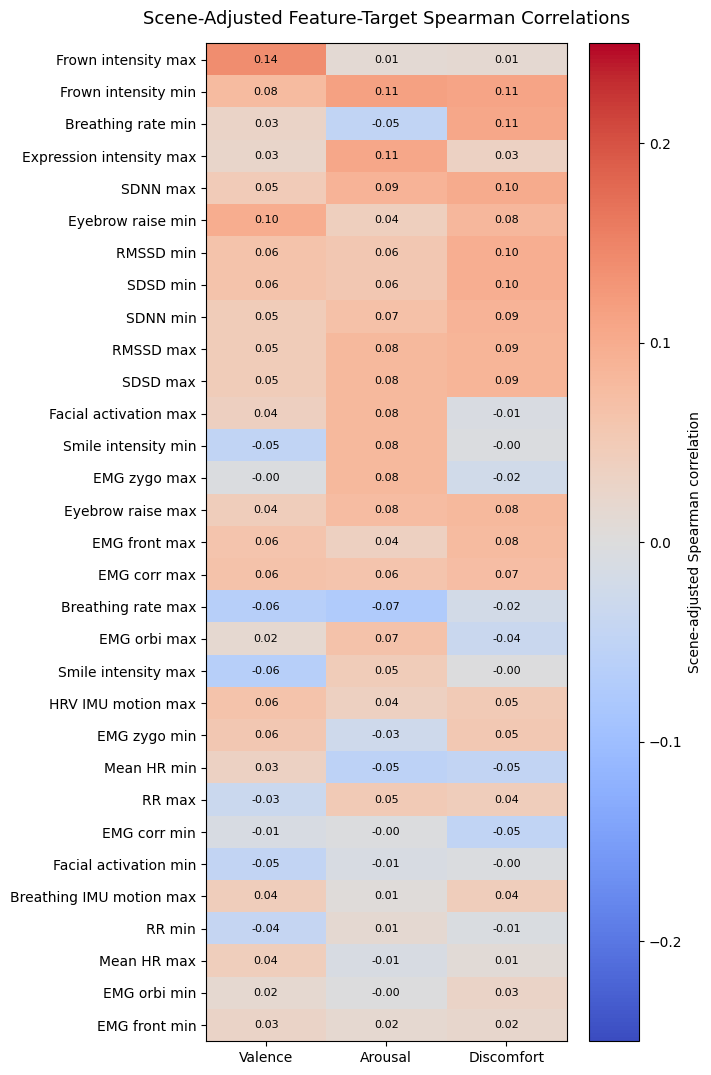

In [53]:
# Scene-adjusted feature-target correlations

target_cols = ["target_valence", "target_arousal"]

if "target_discomfort" in df.columns:
    target_cols.append("target_discomfort")

scene_adjusted_df = df.copy()

cols_to_adjust = feature_cols + target_cols

for col in cols_to_adjust:
    scene_adjusted_df[col + "_scene_centered"] = (
        scene_adjusted_df[col]
        - scene_adjusted_df.groupby("scene_name")[col].transform("mean")
    )

scene_centered_feature_cols = [col + "_scene_centered" for col in feature_cols]
scene_centered_target_cols = [col + "_scene_centered" for col in target_cols]

scene_corr_df = scene_adjusted_df[
    scene_centered_feature_cols + scene_centered_target_cols
].corr(method="spearman")

scene_feature_target_corr = scene_corr_df.loc[
    scene_centered_feature_cols,
    scene_centered_target_cols
]

# Rename rows/columns back to cleaner names
scene_feature_target_corr.index = [
    col.replace("_scene_centered", "") for col in scene_feature_target_corr.index
]

scene_feature_target_corr.columns = [
    col.replace("target_", "").replace("_scene_centered", "").capitalize()
    for col in scene_feature_target_corr.columns
]

# Remove undefined correlations
scene_feature_target_corr_clean = scene_feature_target_corr.dropna(how="all")

# Sort by strongest absolute scene-adjusted correlation
scene_feature_order = (
    scene_feature_target_corr_clean
    .abs()
    .max(axis=1)
    .sort_values(ascending=False)
    .index
)

scene_feature_target_corr_sorted = scene_feature_target_corr_clean.loc[scene_feature_order]

display(scene_feature_target_corr_sorted)

feature_labels = [
    clean_feature_label(feature)
    for feature in scene_feature_target_corr_sorted.index
]

target_labels = scene_feature_target_corr_sorted.columns.tolist()

max_abs_corr = scene_feature_target_corr_sorted.abs().max().max()
color_limit = max(0.25, np.ceil(max_abs_corr * 10) / 10)

plt.figure(figsize=(7, max(7, len(scene_feature_target_corr_sorted) * 0.35)))

im = plt.imshow(
    scene_feature_target_corr_sorted.values,
    vmin=-color_limit,
    vmax=color_limit,
    aspect="auto",
    cmap="coolwarm"
)

plt.colorbar(im, label="Scene-adjusted Spearman correlation")

plt.xticks(
    ticks=np.arange(len(target_labels)),
    labels=target_labels
)

plt.yticks(
    ticks=np.arange(len(feature_labels)),
    labels=feature_labels
)

plt.title("Scene-Adjusted Feature-Target Spearman Correlations", fontsize=13, pad=14)

for i in range(scene_feature_target_corr_sorted.shape[0]):
    for j in range(scene_feature_target_corr_sorted.shape[1]):
        value = scene_feature_target_corr_sorted.iloc[i, j]
        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.show()

## Within Scene Feature Target Correlations

The scene adjusted correlation analysis showed that the overall feature target relationships become weaker after removing average scene level effects. As an additional check, correlations are computed separately within each empathy scene.

This analysis helps determine whether certain feature target relationships appear consistently across scenes or whether they are specific to only one scene. Unlike the previous scene adjusted analysis, this approach keeps the four empathy scenes separate and calculates correlations within each scene independently.


In [54]:
# Within scene feature target correlations

def plot_within_scene_correlations(target_col, title):
    within_scene_corrs = {}

    for scene in scene_order:
        scene_df = df[df["scene_name"] == scene]

        corrs = {}
        for feature in feature_cols:
            if scene_df[feature].nunique(dropna=True) <= 1:
                corrs[feature] = np.nan
            else:
                corrs[feature] = scene_df[[feature, target_col]].corr(method="spearman").iloc[0, 1]

        within_scene_corrs[scene.replace("empathy_", "")] = corrs

    within_scene_corr_df = pd.DataFrame(within_scene_corrs)

    # Remove features with all undefined correlations
    within_scene_corr_df = within_scene_corr_df.dropna(how="all")

    # Sort by strongest absolute correlation in any scene
    feature_order = (
        within_scene_corr_df
        .abs()
        .max(axis=1)
        .sort_values(ascending=False)
        .index
    )

    within_scene_corr_df = within_scene_corr_df.loc[feature_order]

    display(within_scene_corr_df)

    feature_labels = [
        clean_feature_label(feature)
        for feature in within_scene_corr_df.index
    ]

    max_abs_corr = within_scene_corr_df.abs().max().max()
    color_limit = max(0.25, np.ceil(max_abs_corr * 10) / 10)

    plt.figure(figsize=(7, max(7, len(within_scene_corr_df) * 0.35)))

    im = plt.imshow(
        within_scene_corr_df.values,
        vmin=-color_limit,
        vmax=color_limit,
        aspect="auto",
        cmap="coolwarm"
    )

    plt.colorbar(im, label="Spearman correlation")

    plt.xticks(
        ticks=np.arange(len(within_scene_corr_df.columns)),
        labels=within_scene_corr_df.columns
    )

    plt.yticks(
        ticks=np.arange(len(feature_labels)),
        labels=feature_labels
    )

    plt.title(title, fontsize=13, pad=14)

    for i in range(within_scene_corr_df.shape[0]):
        for j in range(within_scene_corr_df.shape[1]):
            value = within_scene_corr_df.iloc[i, j]
            if not pd.isna(value):
                plt.text(
                    j,
                    i,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    fontsize=8
                )

    plt.tight_layout()
    plt.show()

    return within_scene_corr_df

,scene_1,scene_2,scene_3,scene_4
expression_frown_intensity_min,-0.031277,-0.072708,0.235053,-0.008273
breathingrate_imu_motionintensity_max,-0.231461,-0.018068,-0.040690,0.038486
expression_frown_intensity_max,-0.038162,-0.089230,0.222978,-0.006229
emgactivation_emg_amplitude_front_weighted_min,0.054417,-0.025214,-0.030394,0.212355
hrv_imu_motionintensity_max,-0.209321,0.071370,-0.020656,0.029429
facialactivation_facialactivation_min,0.069849,-0.060352,-0.198210,0.053847
expression_smile_intensity_max,-0.130782,0.041331,-0.163283,-0.023773
expression_smile_intensity_min,-0.084875,0.053094,-0.153538,-0.008811
emgactivation_emg_amplitude_zygo_weighted_min,0.151712,-0.081772,-0.001956,0.095730
emgactivation_emg_amplitude_front_weighted_max,0.149396,0.026540,0.036166,0.054788


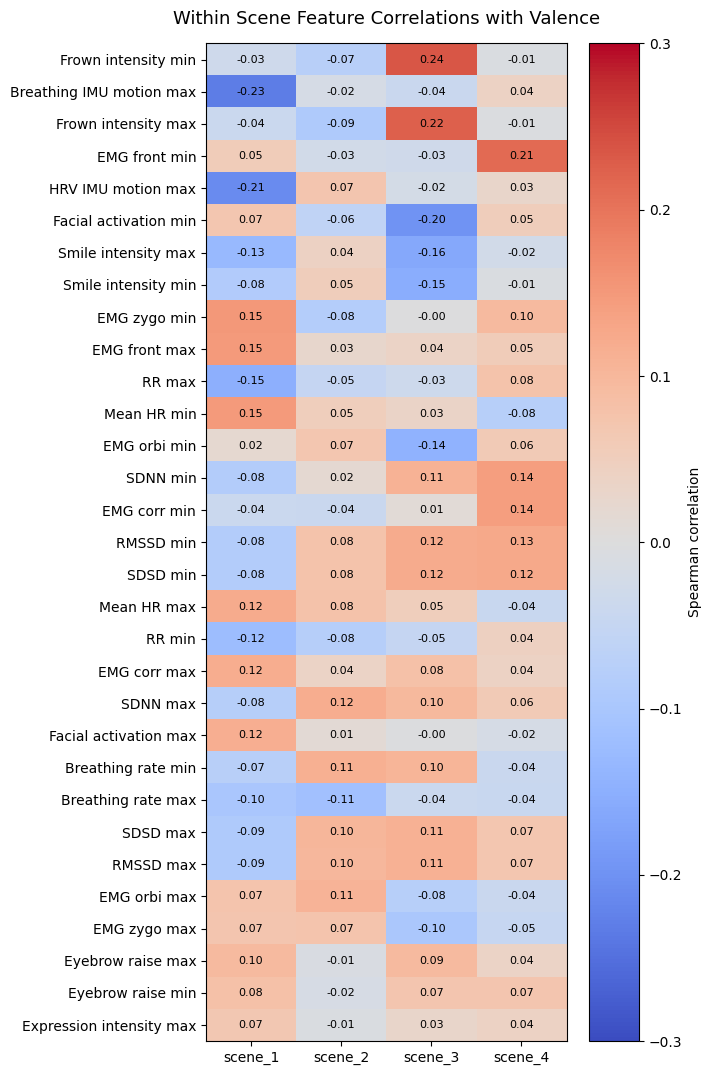

,scene_1,scene_2,scene_3,scene_4
expression_expression_intensity_max,-0.032210,0.088041,0.307917,0.061699
hrv_hrv_sdnn_min,-0.055678,-0.046046,0.111601,0.205697
emgactivation_emg_amplitude_zygo_weighted_max,-0.043568,0.113565,0.197648,0.018533
facialactivation_facialactivation_max,0.042960,0.023132,0.194210,0.039097
hrv_hrv_sdnn_max,-0.014327,0.030111,0.181312,0.119036
expression_smile_intensity_min,-0.037810,0.181115,0.141560,0.051304
hrv_hrv_sdsd_max,-0.003686,0.014015,0.181064,0.111164
hrv_hrv_rmssd_max,-0.003278,0.013136,0.180617,0.110824
hrv_hrv_rmssd_min,-0.058778,-0.021244,0.135949,0.176616
hrv_hrv_sdsd_min,-0.058778,-0.023003,0.136844,0.176616


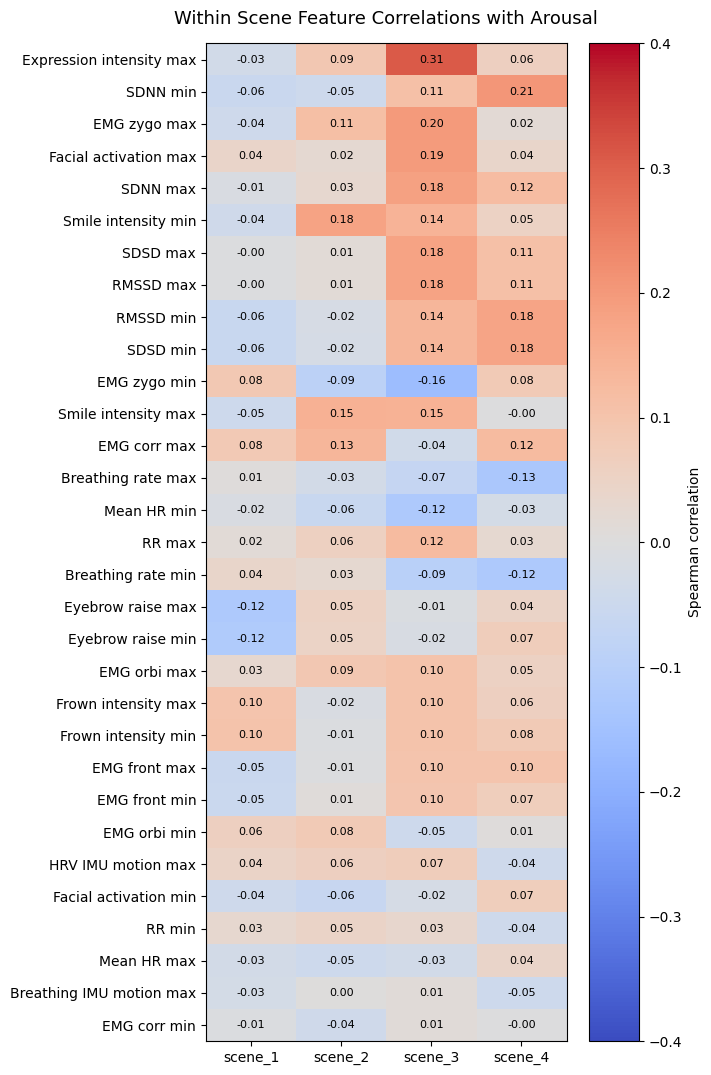

,scene_1,scene_2,scene_3,scene_4
breathingrate_breathingrate_min,0.287690,0.099296,0.028535,0.016232
emgactivation_emg_amplitude_front_weighted_max,0.122029,-0.049765,0.239075,0.140988
emgactivation_emg_amplitude_zygo_weighted_min,0.054838,-0.099112,0.150784,0.225327
emgactivation_emg_amplitude_front_weighted_min,0.010879,-0.022232,0.221277,0.161476
emgactivation_emg_amplitude_corr_weighted_max,0.218901,-0.004494,0.135805,0.073412
hrv_hrv_sdnn_min,-0.061492,0.147723,0.110196,0.170527
hrv_hrv_rmssd_min,-0.031348,0.169492,0.096747,0.151590
hrv_hrv_sdsd_min,-0.031348,0.169091,0.096747,0.151441
expression_eyebrow_raise_intensity_max,0.033578,-0.057888,0.168031,0.040700
expression_frown_intensity_max,0.166775,0.070140,-0.012668,0.012644


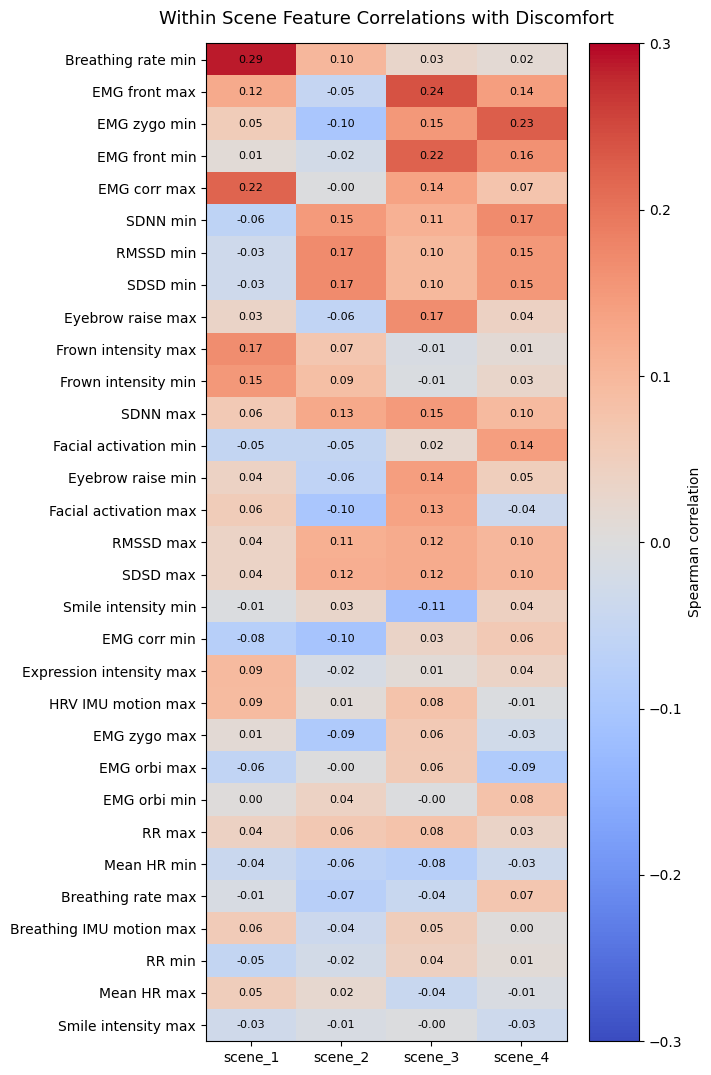

In [55]:
within_scene_valence_corr = plot_within_scene_correlations(
    "target_valence",
    "Within Scene Feature Correlations with Valence"
)

within_scene_arousal_corr = plot_within_scene_correlations(
    "target_arousal",
    "Within Scene Feature Correlations with Arousal"
)

if "target_discomfort" in df.columns:
    within_scene_discomfort_corr = plot_within_scene_correlations(
        "target_discomfort",
        "Within Scene Feature Correlations with Discomfort"
    )

The within scene correlation analysis shows that feature-target relationships are not consistent across all empathy scenes. Instead, several relationships appear to be scene specific.

For valence, most within scene correlations are weak, but some localized patterns are visible. In scene 3, frown intensity shows a positive relationship with valence, while smile related features show weak negative relationships. In scene 4, frontal EMG minimum shows a positive association with valence. These results suggest that valence related facial responses may depend strongly on the scene context.

For arousal, the most visible positive relationships appear in scene 3, where expression intensity, zygomaticus activation, facial activation and several HRV related features show positive correlations with arousal. In scene 4, HRV related features also show positive relationships with arousal. This suggests that arousal may be reflected through different modalities depending on the scene.

For discomfort, some of the clearest relationships are observed for breathing rate in scene 1 and EMG related features in scenes 3 and 4. HRV related features also show weak positive relationships with discomfort across several scenes. However, the correlations remain modest overall.

Overall, the within scene analysis confirms that the relationship between sensor derived features and self reported affective ratings is highly context dependent. The same feature does not necessarily have the same relationship with valence, arousal or discomfort across all scenes. This supports the conclusion that later modeling should treat scene identity and participant variability as important factors rather than assuming one global feature response pattern.


-------

## Conclusion

This exploratory analysis examined the cleaned video level feature dataset for valence and arousal analysis. The final dataset contained 384 samples from 96 participants, with each participant contributing one sample for each of the four empathy scenes. Each sample included minimum and maximum sensor derived features extracted from the corresponding scene window, together with self reported valence, arousal and discomfort ratings.

The target analysis showed that the four empathy scenes produced clearly different subjective responses. Scene 3 was characterized by lower valence, lower arousal and lower discomfort, while scenes 1, 2 and 4 generally produced stronger affective responses. The categorical target analysis showed that arousal was relatively balanced across low, medium and high categories, while valence was more concentrated in the high category and discomfort was more polarized between low and high responses.

The self-report measures were positively related to each other. Valence, arousal and discomfort were not independent, with the strongest relationship observed between valence and discomfort. This suggests that stronger emotional engagement in this dataset may involve multiple affective dimensions at the same time.

The feature analysis showed that the extracted dataset was highly complete, with minimal missing values after quality control. Facial, EMG and expression features showed larger variability across scenes than physiological features such as breathing rate and heart rate. Scene-level feature profiles revealed an important pattern: scene 3 showed high facial and expression-related activation despite low self-reported valence, arousal and discomfort.

Feature comparisons across valence, arousal and discomfort categories showed that the relationship between sensor-derived features and self-reported affective ratings is not straightforward. Higher facial activation did not consistently correspond to higher valence, arousal or discomfort. Instead, several patterns appeared to be influenced by scene identity.

The correlation analyses confirmed this interpretation. Overall feature-target correlations were weak, and after adjusting for scene-level effects they became even weaker. Within-scene correlations showed that some relationships appear only in specific scenes, indicating that feature-response patterns are context-dependent.

Overall, the EDA suggests that affective responses in this dataset are multimodal and scene-dependent. Individual features alone do not strongly explain valence, arousal or discomfort. Therefore, the next stages of analysis should use formal statistical testing and machine learning models that can combine multiple features while accounting for participant-level and scene-level variability.
